In [2]:
# Cell — Join customer_id và product_title từ raw data vào clean files

import pyarrow.dataset as ds
import pyarrow.parquet as pq
import pyarrow as pa
import pandas as pd
import os, gc, time

RAW_DIR   = "/kaggle/input/datasets/datdong123/amazon-clean-v2"
CLEAN_DIR = "/kaggle/input/datasets/nlvdull/cleaned-reviews-data"
OUT_DIR   = "/kaggle/working/fim_ready"
os.makedirs(OUT_DIR, exist_ok=True)

# ── Step 1: Lấy review_id → customer_id + product_title từ raw ───────
# Dùng PyArrow dataset API — lazy scan, không load hết vào RAM
print("Step 1: Scanning raw data for customer_id + product_title...")
t0 = time.time()

raw_files = []
for root, _, fnames in os.walk(RAW_DIR):
    for f in fnames:
        if f.endswith(".parquet"):
            raw_files.append(os.path.join(root, f))

print(f"  Found {len(raw_files)} raw files")

# Load theo từng file, chỉ lấy 3 cột cần thiết
mapping_chunks = []
for i, fpath in enumerate(raw_files):
    chunk = pq.read_table(
        fpath,
        columns=["review_id", "customer_id", "product_title"]
    ).to_pandas()
    mapping_chunks.append(chunk)

    if (i + 1) % 20 == 0:
        print(f"  [{i+1}/{len(raw_files)}]  {time.time()-t0:.0f}s")

mapping_df = pd.concat(mapping_chunks, ignore_index=True)
del mapping_chunks; gc.collect()

print(f"\n  Mapping size: {len(mapping_df):,} rows")
print(f"  Memory: {mapping_df.memory_usage(deep=True).sum()/1024**2:.0f} MB")
print(f"  Done in {time.time()-t0:.0f}s")

Step 1: Scanning raw data for customer_id + product_title...
  Found 200 raw files
  [20/200]  4s
  [40/200]  8s
  [60/200]  12s
  [80/200]  16s
  [100/200]  20s
  [120/200]  24s
  [140/200]  28s
  [160/200]  32s
  [180/200]  36s
  [200/200]  40s

  Mapping size: 31,862,547 rows
  Memory: 6860 MB
  Done in 65s


In [3]:
# Cell — Join và ghi ra file mới theo từng category

print("Step 2: Joining clean files with mapping...")

clean_files = [f for f in os.listdir(CLEAN_DIR) if f.endswith(".parquet")]
print(f"  Found {len(clean_files)} clean category files\n")

for fname in sorted(clean_files):
    t1 = time.time()
    fpath = os.path.join(CLEAN_DIR, fname)
    
    # Load clean file
    clean_df = pd.read_parquet(fpath)
    n_before = len(clean_df)
    
    # Join chỉ lấy 2 cột cần thêm
    enriched = clean_df.merge(
        mapping_df[["review_id", "customer_id", "product_title"]],
        on="review_id",
        how="left"   # giữ tất cả reviews, dù không join được
    )
    
    # Kiểm tra join miss
    n_missing = enriched["customer_id"].isna().sum()
    
    # Ghi ra file mới
    out_path = os.path.join(OUT_DIR, fname)
    enriched.to_parquet(out_path, index=False, compression="snappy")
    
    print(
        f"  {fname:40s} "
        f"rows={n_before:>8,}  "
        f"missing_cust={n_missing:>5,}  "
        f"{time.time()-t1:.0f}s"
    )
    
    del clean_df, enriched; gc.collect()

del mapping_df; gc.collect()
print("\nDone! Verify columns:")
sample = pd.read_parquet(os.path.join(OUT_DIR, clean_files[0])).head(2)
print(sample.columns.tolist())
print(sample[["review_id", "customer_id", "product_id", "product_title"]].head(2))

Step 2: Joining clean files with mapping...
  Found 25 clean category files

  Apparel.parquet                          rows= 269,443  missing_cust=    0  44s
  Automotive.parquet                       rows= 842,073  missing_cust=    0  50s
  Baby.parquet                             rows= 754,586  missing_cust=    0  49s
  Beauty.parquet                           rows=1,014,946  missing_cust=    0  51s
  Books.parquet                            rows= 857,358  missing_cust=    0  56s
  Camera.parquet                           rows= 730,503  missing_cust=    0  52s
  Digital_Ebook_Purchase.parquet           rows=2,358,372  missing_cust=    0  97s
  Digital_Music_Purchase.parquet           rows= 275,351  missing_cust=    0  54s
  Digital_Video_Download.parquet           rows=1,727,660  missing_cust=    0  66s
  Electronics.parquet                      rows=1,253,750  missing_cust=    0  67s
  Grocery.parquet                          rows= 998,702  missing_cust=    0  60s
  Health__Persona

In [4]:
import pyarrow.parquet as pq
import pandas as pd
import numpy as np
from collections import defaultdict, Counter
from itertools import combinations
import os, gc, time

# ── THAY ĐỔI DUY NHẤT: trỏ vào folder vừa join xong ─────────────────
CLEAN_DIR = "/kaggle/working/fim_ready"

CATEGORY         = "Sports"
fname            = "Sports.parquet"
MIN_SUPPORT_FRAC = 0.01
MIN_CONFIDENCE   = 0.3
MIN_LIFT         = 1.0

OUT_DIR = "/kaggle/working/fim_results"
os.makedirs(OUT_DIR, exist_ok=True)

# Verify file tồn tại và có đúng columns
fpath = os.path.join(CLEAN_DIR, fname)
schema = pq.read_schema(fpath)
print("Columns:", schema.names)
print("File exists:", os.path.exists(fpath))

Columns: ['review_id', 'product_id', 'star_rating', 'helpful_votes', 'total_votes', 'helpful_ratio', 'verified_purchase', 'review_headline', 'review_body', 'product_category', 'review_date', 'customer_id', 'product_title']
File exists: True


In [5]:
df = pq.read_table(
    fpath,
    columns=["customer_id", "product_id", "product_title"]
).to_pandas()

print(f"Loaded         : {len(df):,} reviews")
print(f"Unique customers: {df['customer_id'].nunique():,}")
print(f"Unique products : {df['product_id'].nunique():,}")

# Mapping product_id → title để đọc kết quả
product_names = (
    df[["product_id", "product_title"]]
    .drop_duplicates("product_id")
    .set_index("product_id")["product_title"]
    .to_dict()
)

# Build baskets
baskets_raw = (
    df.groupby("customer_id")["product_id"]
    .apply(set)
    .reset_index()
)
baskets_raw.columns = ["customer_id", "items"]
baskets = baskets_raw[baskets_raw["items"].map(len) >= 2]["items"].tolist()
baskets = [frozenset(b) for b in baskets]

NUM_BASKETS     = len(baskets)
MIN_SUPPORT_ABS = max(5, int(MIN_SUPPORT_FRAC * NUM_BASKETS))

print(f"\nBaskets (≥2 products) : {NUM_BASKETS:,}")
print(f"Min support (abs)     : {MIN_SUPPORT_ABS:,}  ({MIN_SUPPORT_FRAC*100:.1f}%)")

# Sanity check — xem vài basket
print("\nSample baskets:")
for cust, items in baskets_raw[baskets_raw["items"].map(len) >= 3].head(3).iterrows():
    names = [product_names.get(p, p)[:30] for p in list(items["items"])[:4]]
    print(f"  {names}")

del df, baskets_raw; gc.collect()

Loaded         : 1,378,105 reviews
Unique customers: 657,791
Unique products : 40,316

Baskets (≥2 products) : 256,693
Min support (abs)     : 2,566  (1.0%)

Sample baskets:
  ['Spalding Varsity Rubber Outdoo', "Velocity Boxing Children's Del", 'Speedo Silicone Solid Swim Cap', 'Valeo Ab Roller Wheel, Exercis']
  ['Valor Fitness DG-1 Stationary ', 'PowerLine PPR200X Power Rack', 'Ironmaster 75 lb Quick-Lock Ad', 'Olympic Grip Plate Weight Set']
  ['NcStar Bipod with Weaver Quick', 'Maglula BabyUpLULA .22LR-.380A', 'Skyline Center Inc. - Gun Clea', "Hoppe's No. 9 Silicone Gun And"]


0

=== Phân phối tần suất product ===
Total unique products trong baskets: 40,247
NUM_BASKETS: 256,693

   Threshold | Min sup (abs) |   L1 size | % products
  -------------------------------------------------------
       0.10% |           256 |       240 |      0.60%
       0.20% |           513 |        50 |      0.12%
       0.50% |         1,283 |         1 |      0.00%
       1.00% |         2,566 |         1 |      0.00%
       2.00% |         5,133 |         0 |      0.00%

  Min sup (abs) |   L1 size | % products |  % of baskets
  ------------------------------------------------------------
              5 |    38,192 |     94.89% |        0.002%
             10 |    26,960 |     66.99% |        0.004%
             20 |    12,614 |     31.34% |        0.008%
             50 |     3,869 |      9.61% |        0.019%
            100 |     1,322 |      3.28% |        0.039%
            200 |       396 |      0.98% |        0.078%
            500 |        54 |      0.13% |        0.19

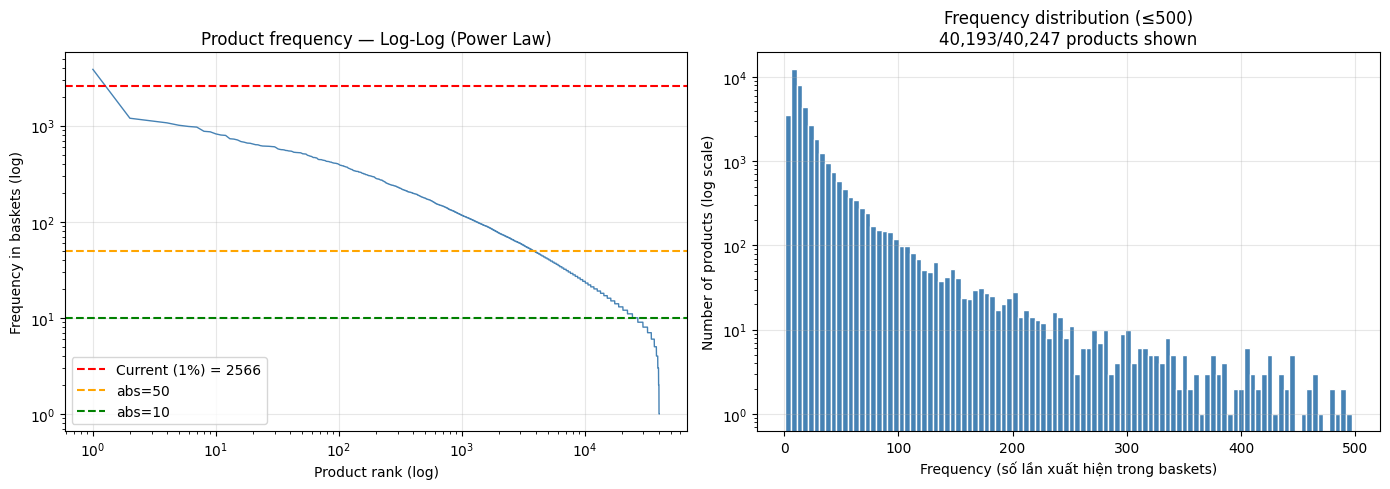


=== Percentiles của product frequency ===
  p 50.0: 13 baskets
  p 75.0: 24 baskets
  p 90.0: 48 baskets
  p 95.0: 76 baskets
  p 99.0: 197 baskets
  p 99.9: 542 baskets
  max  : 3856 baskets


In [6]:
# Cell debug — xem thực tế distribution trước khi chọn threshold

import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# Đếm tần suất xuất hiện của từng product trong baskets
all_items = [item for basket in baskets for item in basket]
item_counts = Counter(all_items)
freqs = np.array(sorted(item_counts.values(), reverse=True))

print("=== Phân phối tần suất product ===")
print(f"Total unique products trong baskets: {len(freqs):,}")
print(f"NUM_BASKETS: {NUM_BASKETS:,}")
print()

# Xem ở các ngưỡng khác nhau có bao nhiêu sản phẩm "sống sót"
thresholds = [0.001, 0.002, 0.005, 0.01, 0.02]
print(f"  {'Threshold':>10s} | {'Min sup (abs)':>13s} | {'L1 size':>9s} | {'% products':>10s}")
print("  " + "-"*55)
for frac in thresholds:
    min_sup = max(5, int(frac * NUM_BASKETS))
    l1_size = (freqs >= min_sup).sum()
    pct     = l1_size / len(freqs) * 100
    print(f"  {frac*100:>9.2f}% | {min_sup:>13,} | {l1_size:>9,} | {pct:>9.2f}%")

# Thêm các ngưỡng tuyệt đối
print()
abs_thresholds = [5, 10, 20, 50, 100, 200, 500]
print(f"  {'Min sup (abs)':>13s} | {'L1 size':>9s} | {'% products':>10s} | {'% of baskets':>13s}")
print("  " + "-"*60)
for min_sup in abs_thresholds:
    l1_size = (freqs >= min_sup).sum()
    pct     = l1_size / len(freqs) * 100
    pct_b   = min_sup / NUM_BASKETS * 100
    print(f"  {min_sup:>13,} | {l1_size:>9,} | {pct:>9.2f}% | {pct_b:>12.3f}%")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Log-log plot — đặc trưng của long-tail
axes[0].loglog(range(1, len(freqs)+1), freqs, color="steelblue", linewidth=1)
axes[0].axhline(y=2566, color="red",    linestyle="--", label=f"Current (1%) = 2566")
axes[0].axhline(y=50,   color="orange", linestyle="--", label="abs=50")
axes[0].axhline(y=10,   color="green",  linestyle="--", label="abs=10")
axes[0].set_xlabel("Product rank (log)")
axes[0].set_ylabel("Frequency in baskets (log)")
axes[0].set_title("Product frequency — Log-Log (Power Law)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Histogram của frequencies (chỉ < 500 để nhìn rõ phần đuôi)
low_freq = freqs[freqs <= 500]
axes[1].hist(low_freq, bins=100, color="steelblue", edgecolor="white", log=True)
axes[1].set_xlabel("Frequency (số lần xuất hiện trong baskets)")
axes[1].set_ylabel("Number of products (log scale)")
axes[1].set_title(f"Frequency distribution (≤500)\n{len(low_freq):,}/{len(freqs):,} products shown")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/frequency_distribution_{CATEGORY}.png", dpi=150)
plt.show()

# Percentiles
print("\n=== Percentiles của product frequency ===")
for p in [50, 75, 90, 95, 99, 99.9]:
    print(f"  p{p:5.1f}: {np.percentile(freqs, p):.0f} baskets")
print(f"  max  : {freqs.max()} baskets")

In [7]:
# Cell — Cập nhật threshold và chạy lại toàn bộ A-Priori

# ── Config mới ────────────────────────────────────────────────────────
MIN_SUPPORT_ABS = 50        # absolute thay vì fraction
MIN_CONFIDENCE  = 0.05      # hạ xuống vì support thấp hơn
MIN_LIFT        = 2.0       # tăng lên để lọc rules có ý nghĩa thật sự

print(f"Config:")
print(f"  MIN_SUPPORT_ABS : {MIN_SUPPORT_ABS}  ({MIN_SUPPORT_ABS/NUM_BASKETS*100:.3f}% baskets)")
print(f"  MIN_CONFIDENCE  : {MIN_CONFIDENCE}")
print(f"  MIN_LIFT        : {MIN_LIFT}")

# ── Pass 1: L1 ────────────────────────────────────────────────────────
print("\n--- Pass 1: Frequent Singletons ---")
t0 = time.time()

singleton_counts = Counter(item for basket in baskets for item in basket)
L1     = {item: cnt for item, cnt in singleton_counts.items() if cnt >= MIN_SUPPORT_ABS}
L1_set = set(L1.keys())

print(f"Done in {time.time()-t0:.1f}s")
print(f"L1 size : {len(L1):,}  (từ {len(singleton_counts):,} unique items)")
print(f"Max candidate pairs: {len(L1)*(len(L1)-1)//2:,}")

print(f"\nTop 10 frequent items:")
for pid, cnt in sorted(L1.items(), key=lambda x: -x[1])[:10]:
    print(f"  {cnt:6,} ({cnt/NUM_BASKETS*100:.2f}%)  {product_names.get(pid,pid)[:60]}")

# ── Pass 2: L2 ────────────────────────────────────────────────────────
print("\n--- Pass 2: Frequent Pairs ---")
t0 = time.time()

pair_counts = Counter()
for basket in baskets:
    filtered = basket & L1_set
    if len(filtered) < 2:
        continue
    for pair in combinations(sorted(filtered), 2):
        pair_counts[pair] += 1

L2 = {pair: cnt for pair, cnt in pair_counts.items() if cnt >= MIN_SUPPORT_ABS}

print(f"Done in {time.time()-t0:.1f}s")
print(f"Candidate pairs    : {len(pair_counts):,}")
print(f"Frequent pairs (L2): {len(L2):,}")

print(f"\nTop 10 frequent pairs:")
for (a,b), cnt in sorted(L2.items(), key=lambda x: -x[1])[:10]:
    ta = product_names.get(a,a)[:35]
    tb = product_names.get(b,b)[:35]
    print(f"  {cnt:6,} ({cnt/NUM_BASKETS*100:.2f}%)  {ta}  ←→  {tb}")

del pair_counts; gc.collect()

# ── Pass 3: L3 ────────────────────────────────────────────────────────
print("\n--- Pass 3: Frequent Triples ---")
t0 = time.time()

L2_set        = set(L2.keys())
triple_counts = Counter()
n_pruned      = 0

for basket in baskets:
    filtered = sorted(basket & L1_set)
    if len(filtered) < 3:
        continue
    for triple in combinations(filtered, 3):
        a, b, c = triple
        if (a,b) in L2_set and (a,c) in L2_set and (b,c) in L2_set:
            triple_counts[triple] += 1
        else:
            n_pruned += 1

L3 = {t: cnt for t, cnt in triple_counts.items() if cnt >= MIN_SUPPORT_ABS}

print(f"Done in {time.time()-t0:.1f}s")
print(f"Candidates generated : {len(triple_counts):,}")
print(f"Pruned by A-Priori   : {n_pruned:,}")
print(f"Frequent triples (L3): {len(L3):,}")

if len(L3) > 0:
    print(f"\nTop 10 frequent triples:")
    for triple, cnt in sorted(L3.items(), key=lambda x: -x[1])[:10]:
        names = " | ".join(product_names.get(i,i)[:20] for i in triple)
        print(f"  {cnt:6,} ({cnt/NUM_BASKETS*100:.2f}%)  {names}")
else:
    print("  → Không có triple, thử giảm MIN_SUPPORT_ABS xuống 20")

del triple_counts; gc.collect()

# ── Summary ───────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"SUMMARY")
print(f"{'='*60}")
print(f"  NUM_BASKETS : {NUM_BASKETS:,}")
print(f"  L1 (items)  : {len(L1):,}")
print(f"  L2 (pairs)  : {len(L2):,}")
print(f"  L3 (triples): {len(L3):,}")

Config:
  MIN_SUPPORT_ABS : 50  (0.019% baskets)
  MIN_CONFIDENCE  : 0.05
  MIN_LIFT        : 2.0

--- Pass 1: Frequent Singletons ---
Done in 0.3s
L1 size : 3,869  (từ 40,247 unique items)
Max candidate pairs: 7,482,646

Top 10 frequent items:
   3,856 (1.50%)  1006409 Maglula UpLULA Universal Pistol Magazine Loader
   1,195 (0.47%)  Single Point Tactical Rifle Sling Black
   1,120 (0.44%)  SE KHK6320 Outdoor Tanto Knife with Fire Starter
   1,070 (0.42%)  Maglula ltd LULA Speed Loader and Unloader for M-16/ AR-15
   1,010 (0.39%)  Ade Advanced Optics Front/Rear 45-Degree Rapid Transition BU
     981 (0.38%)  UTG Tactical OP Bipod, Rubber Feet, Center Height 8.3"-12.7"
     966 (0.38%)  Bushnell Trophy TRS-25 Red Dot Sight Riflescope, 1 x 25mm (t
     874 (0.34%)  McDavid Waist Trimmer Ab belt- Weight Loss- Abdominal Muscle
     863 (0.34%)  UTG Tactical OP Bipod, Rubber Feet, Center Height 6.1"-7.9"
     821 (0.32%)  Black Mountain Products Resistance Band Set with Door Anchor

--- P

In [8]:
# Mục đích: chứng minh time-windowed basket tốt hơn full-history
# trên cùng 1 dataset → loại bỏ biến số "khác category"

import pandas as pd
import numpy as np
import pyarrow.parquet as pq
from collections import Counter
from itertools import combinations
import matplotlib.pyplot as plt
import os, gc, time

FIM_READY_DIR = "/kaggle/working/fim_ready"
OUT_DIR       = "/kaggle/working/fim_results"
os.makedirs(OUT_DIR, exist_ok=True)

# Load Sports với review_date
df_sports = pq.read_table(
    os.path.join(FIM_READY_DIR, "Sports.parquet"),
    columns=["customer_id", "product_id", "product_title", "review_date"]
).to_pandas()
df_sports["review_date"] = pd.to_datetime(df_sports["review_date"])

print(f"Sports loaded: {len(df_sports):,} reviews")
print(f"Date range: {df_sports['review_date'].min().date()} "
      f"→ {df_sports['review_date'].max().date()}")

Sports loaded: 1,378,105 reviews
Date range: 1999-11-18 → 2015-08-31


Full-history: 256,693 baskets  |  median size = 3.0
Window  7d: 200,710 baskets  |  median size = 2.0  |  avg top-10 support = 885
Window 14d: 205,328 baskets  |  median size = 2.0  |  avg top-10 support = 907
Window 30d: 211,831 baskets  |  median size = 2.0  |  avg top-10 support = 947
Window 60d: 219,659 baskets  |  median size = 2.0  |  avg top-10 support = 988
Window 90d: 224,118 baskets  |  median size = 2.0  |  avg top-10 support = 1017


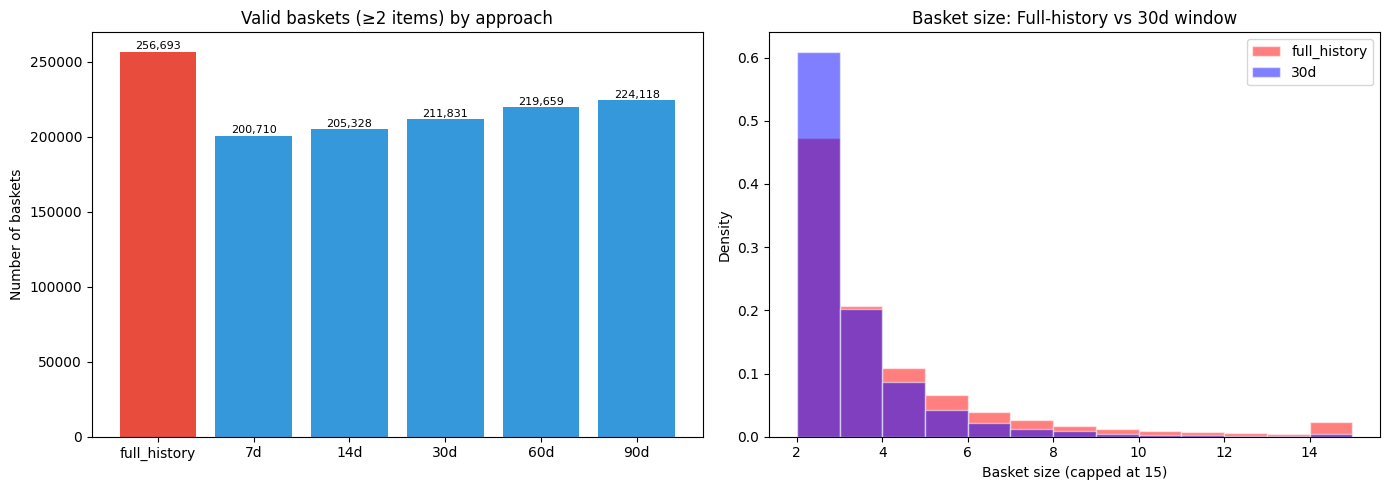

In [9]:
# Mục đích: chọn window size tốt nhất trước khi chạy A-Priori
# Logic: window_index = unix_timestamp // (window_days * 86400)
# → Tất cả reviews của cùng 1 user trong cùng window → 1 basket

results = {}

# Full-history (baseline hiện tại)
fh = df_sports.groupby("customer_id")["product_id"].apply(frozenset)
fh_valid = [b for b in fh if len(b) >= 2]
results["full_history"] = fh_valid
print(f"Full-history: {len(fh_valid):,} baskets  |  "
      f"median size = {np.median([len(b) for b in fh_valid]):.1f}")

# Time-windowed
for wd in [7, 14, 30, 60, 90]:
    df_sports["win"] = (
        df_sports["review_date"].astype("int64") // 10**9
        // (wd * 86400)
    )
    tw = (
        df_sports.groupby(["customer_id", "win"])["product_id"]
        .apply(frozenset)
        .reset_index()["product_id"]
    )
    tw_valid = [b for b in tw if len(b) >= 2]
    results[f"{wd}d"] = tw_valid

    # Tính median support của top items để đánh giá
    if tw_valid:
        all_items = [i for b in tw_valid for i in b]
        top_sup   = sorted(Counter(all_items).values(), reverse=True)[:10]
        avg_top   = np.mean(top_sup)
    else:
        avg_top = 0

    print(f"Window {wd:2d}d: {len(tw_valid):,} baskets  |  "
          f"median size = {np.median([len(b) for b in tw_valid]) if tw_valid else 0:.1f}  |  "
          f"avg top-10 support = {avg_top:.0f}")

# Plot so sánh
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Số baskets valid
labels = list(results.keys())
counts = [len(v) for v in results.values()]
colors = ["#e74c3c"] + ["#3498db"] * (len(labels)-1)
bars   = axes[0].bar(labels, counts, color=colors)
axes[0].set_title("Valid baskets (≥2 items) by approach")
axes[0].set_ylabel("Number of baskets")
for bar, cnt in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 100,
                 f"{cnt:,}", ha="center", va="bottom", fontsize=8)

# Distribution basket size (30d vs full-history)
for label, color in [("full_history","red"), ("30d","blue")]:
    sizes = np.clip([len(b) for b in results[label]], 2, 15)
    axes[1].hist(sizes, bins=range(2,16), alpha=0.5,
                 label=label, color=color, density=True, edgecolor="white")
axes[1].set_xlabel("Basket size (capped at 15)")
axes[1].set_ylabel("Density")
axes[1].set_title("Basket size: Full-history vs 30d window")
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/basket_comparison_Sports.png", dpi=150)
plt.show()

=== Grocery Dataset ===
Tổng reviews    : 998,702
Unique customers: 483,108
Unique products : 32,006
Khoảng thời gian: 2001-10-26 → 2015-08-31

=== Số sản phẩm mỗi người đã review ===
  Trung bình : 2.1 sản phẩm/người
  50% người  : ≤ 1 sản phẩm
  90% người  : ≤ 4 sản phẩm
  Nhiều nhất : 278 sản phẩm

=== Basket size theo window size ===
             Cách |  Số giỏ hàng |  Median size |  % giỏ có ≥3 món
  --------------------------------------------------------------
     full_history |      192,605 |          3.0 |            50.3%
               7d |      133,955 |          2.0 |            31.0%
              14d |      137,810 |          2.0 |            31.7%
              30d |      143,935 |          2.0 |            32.9%
              60d |      152,211 |          2.0 |            34.7%
              90d |      157,537 |          2.0 |            35.9%


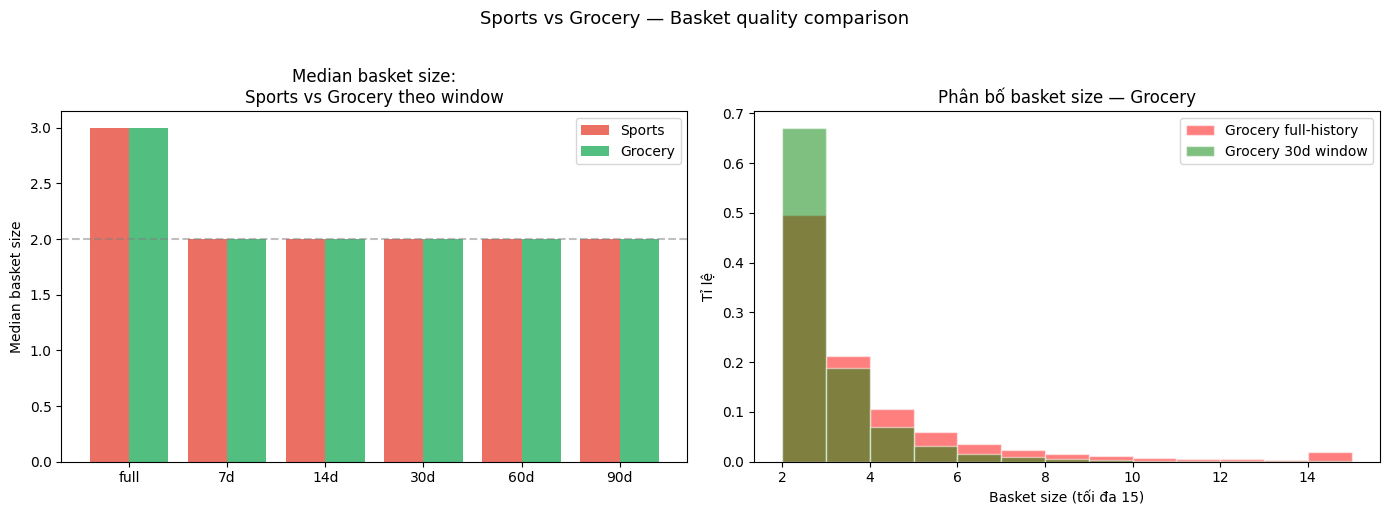

In [12]:
# Mục đích: xem Grocery có basket size tốt hơn Sports không
# Trước khi chạy A-Priori tốn thời gian, cần kiểm tra data trước

import pandas as pd
import numpy as np
import pyarrow.parquet as pq
from collections import Counter
import matplotlib.pyplot as plt
import os, gc

FIM_READY_DIR = "/kaggle/working/fim_ready"
OUT_DIR       = "/kaggle/working/fim_results"

# Load Grocery — chỉ lấy 4 cột cần thiết
df_grocery = pq.read_table(
    os.path.join(FIM_READY_DIR, "Grocery.parquet"),
    columns=["customer_id", "product_id", "product_title", "review_date"]
).to_pandas()
df_grocery["review_date"] = pd.to_datetime(df_grocery["review_date"])

# Lưu tên sản phẩm để đọc kết quả dễ hơn
product_names = (
    df_grocery[["product_id", "product_title"]]
    .drop_duplicates("product_id")
    .set_index("product_id")["product_title"]
    .to_dict()
)

print(f"=== Grocery Dataset ===")
print(f"Tổng reviews    : {len(df_grocery):,}")
print(f"Unique customers: {df_grocery['customer_id'].nunique():,}")
print(f"Unique products : {df_grocery['product_id'].nunique():,}")
print(f"Khoảng thời gian: {df_grocery['review_date'].min().date()} "
      f"→ {df_grocery['review_date'].max().date()}")

# Xem mỗi người trung bình review bao nhiêu sản phẩm
reviews_per_user = df_grocery.groupby("customer_id").size()
print(f"\n=== Số sản phẩm mỗi người đã review ===")
print(f"  Trung bình : {reviews_per_user.mean():.1f} sản phẩm/người")
print(f"  50% người  : ≤ {reviews_per_user.median():.0f} sản phẩm")
print(f"  90% người  : ≤ {np.percentile(reviews_per_user, 90):.0f} sản phẩm")
print(f"  Nhiều nhất : {reviews_per_user.max()} sản phẩm")

# So sánh basket size giữa các window sizes
# Giống như bước phân tích Sports ở trên
print(f"\n=== Basket size theo window size ===")
print(f"  {'Cách':>15s} | {'Số giỏ hàng':>12s} | {'Median size':>12s} | "
      f"{'% giỏ có ≥3 món':>16s}")
print("  " + "-"*62)

grocery_results = {}

for wd in ["full", 7, 14, 30, 60, 90]:
    if wd == "full":
        grp = df_grocery.groupby("customer_id")["product_id"].apply(frozenset)
        label = "full_history"
    else:
        df_grocery["win"] = (
            df_grocery["review_date"].astype("int64") // 10**9
            // (wd * 86400)
        )
        grp = (
            df_grocery
            .groupby(["customer_id", "win"])["product_id"]
            .apply(frozenset)
            .reset_index()["product_id"]
        )
        label = f"{wd}d"

    valid = [b for b in grp if len(b) >= 2]
    grocery_results[label] = valid

    if valid:
        sizes     = [len(b) for b in valid]
        pct_3plus = sum(1 for s in sizes if s >= 3) / len(sizes) * 100
        print(f"  {label:>15s} | {len(valid):>12,} | "
              f"{np.median(sizes):>12.1f} | {pct_3plus:>15.1f}%")

# Vẽ biểu đồ so sánh Grocery vs Sports
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# So sánh median basket size: Sports vs Grocery
labels_plot  = ["full", "7d", "14d", "30d", "60d", "90d"]
sports_medians  = [
    np.median([len(b) for b in results["full_history"]]),
    np.median([len(b) for b in results["7d"]]),
    np.median([len(b) for b in results["14d"]]),
    np.median([len(b) for b in results["30d"]]),
    np.median([len(b) for b in results["60d"]]),
    np.median([len(b) for b in results["90d"]]),
]
grocery_medians = [
    np.median([len(b) for b in grocery_results["full_history"]]),
    np.median([len(b) for b in grocery_results["7d"]]),
    np.median([len(b) for b in grocery_results["14d"]]),
    np.median([len(b) for b in grocery_results["30d"]]),
    np.median([len(b) for b in grocery_results["60d"]]),
    np.median([len(b) for b in grocery_results["90d"]]),
]

x = np.arange(len(labels_plot))
axes[0].bar(x - 0.2, sports_medians,  0.4, label="Sports",  color="#e74c3c", alpha=0.8)
axes[0].bar(x + 0.2, grocery_medians, 0.4, label="Grocery", color="#27ae60", alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels_plot)
axes[0].set_ylabel("Median basket size")
axes[0].set_title("Median basket size:\nSports vs Grocery theo window")
axes[0].legend()
axes[0].axhline(y=2, color="gray", linestyle="--", alpha=0.5, label="size=2 (tối thiểu)")

# Histogram basket size Grocery 30d
sizes_30d = np.clip([len(b) for b in grocery_results["30d"]], 2, 15)
sizes_fh  = np.clip([len(b) for b in grocery_results["full_history"]], 2, 15)
axes[1].hist(sizes_fh,  bins=range(2,16), alpha=0.5, color="red",
             label="Grocery full-history", density=True, edgecolor="white")
axes[1].hist(sizes_30d, bins=range(2,16), alpha=0.5, color="green",
             label="Grocery 30d window",  density=True, edgecolor="white")
axes[1].set_xlabel("Basket size (tối đa 15)")
axes[1].set_ylabel("Tỉ lệ")
axes[1].set_title("Phân bố basket size — Grocery")
axes[1].legend()

plt.suptitle("Sports vs Grocery — Basket quality comparison", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/basket_comparison_Grocery_vs_Sports.png", dpi=150)
plt.show()

In [13]:
# Mục đích: tìm ngưỡng MIN_SUPPORT phù hợp trước khi chạy A-Priori
# Grocery full_history đã có sẵn trong grocery_results["full_history"]

from itertools import combinations

baskets     = grocery_results["full_history"]
NUM_BASKETS = len(baskets)

# Đếm tần suất xuất hiện của từng sản phẩm trong các giỏ hàng
all_items   = [item for basket in baskets for item in basket]
item_counts = Counter(all_items)
freqs       = np.array(sorted(item_counts.values(), reverse=True))

print(f"=== Grocery Full-history ===")
print(f"Số giỏ hàng hợp lệ : {NUM_BASKETS:,}")
print(f"Unique sản phẩm    : {len(freqs):,}")

print(f"\n=== Tần suất sản phẩm ===")
print(f"  50% sản phẩm xuất hiện ≤ {np.percentile(freqs, 50):.0f} lần")
print(f"  75% sản phẩm xuất hiện ≤ {np.percentile(freqs, 75):.0f} lần")
print(f"  90% sản phẩm xuất hiện ≤ {np.percentile(freqs, 90):.0f} lần")
print(f"  95% sản phẩm xuất hiện ≤ {np.percentile(freqs, 95):.0f} lần")
print(f"  Sản phẩm phổ biến nhất  : {freqs.max()} lần")

# Xem nếu chọn các ngưỡng khác nhau thì còn bao nhiêu sản phẩm
print(f"\n=== Nếu chọn ngưỡng tối thiểu ===")
print(f"  {'Ngưỡng':>8s} | {'Sản phẩm còn lại':>18s} | {'Max cặp cần xét':>17s} | Ghi chú")
print("  " + "-"*75)
for sup in [5, 10, 20, 30, 50, 100, 200]:
    l1       = (freqs >= sup).sum()
    max_pair = l1 * (l1-1) // 2
    pct      = l1 / len(freqs) * 100

    # Đánh giá
    if max_pair > 5_000_000:
        note = "⚠️  quá nhiều cặp, chậm"
    elif l1 < 100:
        note = "⚠️  quá ít sản phẩm"
    elif 200 <= l1 <= 2000:
        note = "✅ phù hợp"
    else:
        note = ""

    print(f"  {sup:>8,} | {l1:>12,} ({pct:4.1f}%) | {max_pair:>17,} | {note}")

# Top 20 sản phẩm phổ biến nhất — để xem Grocery có coherent không
print(f"\n=== Top 20 sản phẩm phổ biến nhất ===")
print(f"  {'Lần xuất hiện':>15s} | Tên sản phẩm")
print("  " + "-"*70)
for pid, cnt in sorted(item_counts.items(), key=lambda x: -x[1])[:20]:
    name = product_names.get(pid, pid)[:60]
    print(f"  {cnt:>15,} | {name}")

=== Grocery Full-history ===
Số giỏ hàng hợp lệ : 192,605
Unique sản phẩm    : 31,990

=== Tần suất sản phẩm ===
  50% sản phẩm xuất hiện ≤ 13 lần
  75% sản phẩm xuất hiện ≤ 23 lần
  90% sản phẩm xuất hiện ≤ 43 lần
  95% sản phẩm xuất hiện ≤ 65 lần
  Sản phẩm phổ biến nhất  : 2156 lần

=== Nếu chọn ngưỡng tối thiểu ===
    Ngưỡng |   Sản phẩm còn lại |   Max cặp cần xét | Ghi chú
  ---------------------------------------------------------------------------
         5 |       30,938 (96.7%) |       478,564,453 | ⚠️  quá nhiều cặp, chậm
        10 |       21,399 (66.9%) |       228,947,901 | ⚠️  quá nhiều cặp, chậm
        20 |        9,851 (30.8%) |        48,516,175 | ⚠️  quá nhiều cặp, chậm
        30 |        5,765 (18.0%) |        16,614,730 | ⚠️  quá nhiều cặp, chậm
        50 |        2,474 ( 7.7%) |         3,059,101 | 
       100 |          731 ( 2.3%) |           266,815 | ✅ phù hợp
       200 |          196 ( 0.6%) |            19,110 | 

=== Top 20 sản phẩm phổ biến nhất ===


In [14]:
from itertools import combinations
import time

MIN_SUPPORT_ABS = 50
MIN_CONFIDENCE  = 0.05   # 5% — nghĩa là: trong 100 người mua A, ít nhất 5 người cũng mua B
MIN_LIFT        = 2.0    # lift > 2 — A và B cùng xuất hiện ít nhất gấp 2 lần so với ngẫu nhiên

print(f"=== A-Priori trên Grocery Full-history ===")
print(f"Số giỏ hàng : {NUM_BASKETS:,}")
print(f"Ngưỡng tối thiểu : sản phẩm phải xuất hiện trong ít nhất {MIN_SUPPORT_ABS} giỏ hàng")
print()

# ── Pass 1: Tìm sản phẩm phổ biến (L1) ───────────────────────────────
# Đếm từng sản phẩm xuất hiện bao nhiêu lần trong tất cả giỏ hàng
# Loại bỏ sản phẩm xuất hiện ít hơn MIN_SUPPORT_ABS lần
t0 = time.time()

singleton_counts = Counter(item for basket in baskets for item in basket)
L1     = {item: cnt for item, cnt in singleton_counts.items()
          if cnt >= MIN_SUPPORT_ABS}
L1_set = set(L1.keys())

print(f"Pass 1 xong [{time.time()-t0:.1f}s]")
print(f"  Tổng sản phẩm unique  : {len(singleton_counts):,}")
print(f"  Sản phẩm đủ điều kiện : {len(L1):,}  (xuất hiện ≥ {MIN_SUPPORT_ABS} lần)")
print(f"  Sản phẩm bị loại      : {len(singleton_counts)-len(L1):,}")
print(f"  Số cặp cần xét tối đa : {len(L1)*(len(L1)-1)//2:,}")

print(f"\n  Top 15 sản phẩm phổ biến nhất:")
for pid, cnt in sorted(L1.items(), key=lambda x: -x[1])[:15]:
    name = product_names.get(pid, pid)[:65]
    print(f"    {cnt:5,} lần  |  {name}")

# ── Pass 2: Tìm cặp sản phẩm phổ biến (L2) ───────────────────────────
# Với mỗi giỏ hàng, chỉ giữ lại sản phẩm thuộc L1
# Sau đó tạo tất cả cặp 2 sản phẩm trong giỏ đó và đếm
t0 = time.time()
pair_counts = Counter()

for basket in baskets:
    # Chỉ giữ sản phẩm đã vượt ngưỡng L1 — bỏ qua sản phẩm hiếm
    filtered = basket & L1_set
    if len(filtered) < 2:
        continue
    for pair in combinations(sorted(filtered), 2):
        pair_counts[pair] += 1

L2 = {pair: cnt for pair, cnt in pair_counts.items()
      if cnt >= MIN_SUPPORT_ABS}

print(f"\nPass 2 xong [{time.time()-t0:.1f}s]")
print(f"  Tổng cặp đã đếm       : {len(pair_counts):,}")
print(f"  Cặp đủ điều kiện (L2) : {len(L2):,}")
print(f"  Cặp bị loại           : {len(pair_counts)-len(L2):,}")

print(f"\n  Top 15 cặp sản phẩm thường đi cùng nhau:")
print(f"  {'Số lần':>7s} | Sản phẩm A  ←→  Sản phẩm B")
print("  " + "-"*80)
for (a,b), cnt in sorted(L2.items(), key=lambda x: -x[1])[:15]:
    ta = product_names.get(a, a)[:35]
    tb = product_names.get(b, b)[:35]
    print(f"  {cnt:7,} | {ta}  ←→  {tb}")

del pair_counts; gc.collect()

# ── Pass 3: Tìm bộ 3 sản phẩm phổ biến (L3) ──────────────────────────
# Chỉ xét bộ 3 nếu TẤT CẢ 3 cặp con của nó đều có trong L2
# Ví dụ: {A,B,C} chỉ được xét nếu {A,B}, {A,C}, {B,C} đều trong L2
# → Đây là "A-Priori pruning" — cắt bớt để không phải xét tất cả bộ 3
t0    = time.time()
L2_set = set(L2.keys())
triple_counts = Counter()
n_pruned = 0

for basket in baskets:
    filtered = sorted(basket & L1_set)
    if len(filtered) < 3:
        continue
    for triple in combinations(filtered, 3):
        a, b, c = triple
        # Kiểm tra 3 cặp con: (a,b), (a,c), (b,c)
        if (a,b) in L2_set and (a,c) in L2_set and (b,c) in L2_set:
            triple_counts[triple] += 1
        else:
            n_pruned += 1   # bị cắt bởi A-Priori

L3 = {t: cnt for t, cnt in triple_counts.items() if cnt >= MIN_SUPPORT_ABS}

print(f"\nPass 3 xong [{time.time()-t0:.1f}s]")
print(f"  Bộ 3 đã xét           : {len(triple_counts):,}")
print(f"  Bộ 3 bị cắt (A-Priori): {n_pruned:,}")
print(f"  Bộ 3 đủ điều kiện (L3): {len(L3):,}")

if len(L3) > 0:
    print(f"\n  Top 10 bộ 3 sản phẩm thường đi cùng nhau:")
    for triple, cnt in sorted(L3.items(), key=lambda x: -x[1])[:10]:
        names = "\n           ".join(
            f"  • {product_names.get(i,i)[:65]}" for i in triple
        )
        print(f"\n  {cnt:5,} lần:\n{names}")
else:
    print("\n  Không có bộ 3 nào — sẽ thử giảm ngưỡng xuống 20 nếu cần")

del triple_counts; gc.collect()

print(f"\n{'='*55}")
print(f"  TỔNG KẾT")
print(f"{'='*55}")
print(f"  L1 — Sản phẩm phổ biến : {len(L1):,}")
print(f"  L2 — Cặp phổ biến      : {len(L2):,}")
print(f"  L3 — Bộ 3 phổ biến     : {len(L3):,}")

=== A-Priori trên Grocery Full-history ===
Số giỏ hàng : 192,605
Ngưỡng tối thiểu : sản phẩm phải xuất hiện trong ít nhất 50 giỏ hàng

Pass 1 xong [0.3s]
  Tổng sản phẩm unique  : 31,990
  Sản phẩm đủ điều kiện : 2,474  (xuất hiện ≥ 50 lần)
  Sản phẩm bị loại      : 29,516
  Số cặp cần xét tối đa : 3,059,101

  Top 15 sản phẩm phổ biến nhất:
    2,156 lần  |  Viva Naturals Organic Extra Virgin Coconut Oil, 16 Ounce
    1,716 lần  |  San Francisco Bay One Cup
    1,359 lần  |  San Francisco Bay One Cup
    1,279 lần  |  Keurig, The Original Donut Shop, K-Cup packs
    1,118 lần  |  KIND Bars, Dark Chocolate Nuts & Sea Salt 12ct, Gluten Free, 6g P
    1,101 lần  |  Brooklyn Beans Single-cup Coffee for Keurig K-Cup Brewers, 40-Cou
    1,099 lần  |  Nutiva Organic Virgin Coconut Oil, 15 Ounce
    1,037 lần  |  Ekobrew Coffee Reusable Filter, Small, Violet
      954 lần  |  Grove Square Cappuccino, Single Serve Cup for Keurig K-Cup Brewer
      891 lần  |  San Francisco Bay One Cup
      84

cùng 1 sản phẩm thường được bán bởi nhiều người bán khác nhau → mỗi người bán có product_id riêng → nhưng tên sản phẩm giống nhau -> vô nghĩa
Vấn đề gốc rễ: product_id không đáng tin cậy để identify sản phẩm
Giải pháp    : Gộp các product_id có cùng product_title thành 1
               → "San Francisco Bay One Cup" dù bao nhiêu ID cũng = 1 sản phẩm

Sau khi fix:
  → Loại bỏ được cặp giả (self-pairs)
  → Support của các sản phẩm phổ biến tăng lên (vì gộp lại)
  → Kỳ vọng L2 tăng, L3 xuất hiện

In [15]:
# Mục đích: đo xem có bao nhiêu sản phẩm bị trùng tên trước khi fix

print("=== Kiểm tra duplicate product_id ===\n")

# Đếm có bao nhiêu product_id khác nhau cho cùng 1 tên sản phẩm
title_to_ids = df_grocery.groupby("product_title")["product_id"].nunique()

print(f"Tổng unique product_title : {len(title_to_ids):,}")
print(f"Tổng unique product_id    : {df_grocery['product_id'].nunique():,}")
print(f"Chênh lệch                : {df_grocery['product_id'].nunique() - len(title_to_ids):,} IDs thừa")

print(f"\nPhân bố số product_id trên mỗi tên sản phẩm:")
print(f"  {'Số ID':>6s} | {'Số tên SP':>10s} | Ghi chú")
print("  " + "-"*45)
for n_ids, count in sorted(title_to_ids.value_counts().items()):
    note = "← tên này có đúng 1 ID (bình thường)" if n_ids == 1 else \
           f"← {count:,} tên SP bị chia thành {n_ids} ID khác nhau"
    print(f"  {n_ids:>6d} | {count:>10,} | {note}")
    if n_ids > 10:
        break

# Xem ví dụ cụ thể — San Francisco Bay bị chia thành mấy ID
print(f"\nVí dụ: 'San Francisco Bay One Cup' có mấy product_id?")
sfb = df_grocery[df_grocery["product_title"].str.contains(
    "San Francisco Bay One Cup", na=False
)][["product_id","product_title"]].drop_duplicates()
print(sfb.to_string(index=False))

print(f"\nVí dụ: 'Nutiva Organic Virgin Coconut Oil' có mấy product_id?")
nutiva = df_grocery[df_grocery["product_title"].str.contains(
    "Nutiva Organic Virgin Coconut Oil", na=False
)][["product_id","product_title"]].drop_duplicates()
print(nutiva.to_string(index=False))

=== Kiểm tra duplicate product_id ===

Tổng unique product_title : 26,194
Tổng unique product_id    : 32,006
Chênh lệch                : 5,812 IDs thừa

Phân bố số product_id trên mỗi tên sản phẩm:
   Số ID |  Số tên SP | Ghi chú
  ---------------------------------------------
       1 |     23,842 | ← tên này có đúng 1 ID (bình thường)
       2 |      1,336 | ← 1,336 tên SP bị chia thành 2 ID khác nhau
       3 |        389 | ← 389 tên SP bị chia thành 3 ID khác nhau
       4 |        200 | ← 200 tên SP bị chia thành 4 ID khác nhau
       5 |        126 | ← 126 tên SP bị chia thành 5 ID khác nhau
       6 |         86 | ← 86 tên SP bị chia thành 6 ID khác nhau
       7 |         58 | ← 58 tên SP bị chia thành 7 ID khác nhau
       8 |         38 | ← 38 tên SP bị chia thành 8 ID khác nhau
       9 |         28 | ← 28 tên SP bị chia thành 9 ID khác nhau
      10 |         15 | ← 15 tên SP bị chia thành 10 ID khác nhau
      11 |         12 | ← 12 tên SP bị chia thành 11 ID khác nhau

Ví

In [16]:
# Mục đích: thay product_id bằng product_title (đã chuẩn hóa)
# Sau bước này, "San Francisco Bay One Cup" dù mua từ seller nào
# cũng được tính là CÙNG 1 sản phẩm

import re

def normalize_title(title: str) -> str:
    """
    Chuẩn hóa tên sản phẩm để gộp các biến thể lại:
      1. Lowercase
      2. Bỏ số lượng ở cuối (vd: "80-count", "16 oz", "2 pack")
      3. Strip khoảng trắng thừa
    """
    t = str(title).lower().strip()
    # Bỏ thông tin số lượng/kích thước ở cuối tên
    t = re.sub(r'\b\d+[\s-]?(count|pack|oz|ounce|lb|pound|ct|g|gram|ml|liter)s?\b',
               '', t)
    t = re.sub(r'\s+', ' ', t).strip()
    return t

# Tạo mapping: product_id → normalized_title
# Đây sẽ là "ID sản phẩm mới" của chúng ta
df_grocery["norm_title"] = df_grocery["product_title"].apply(normalize_title)

# Kiểm tra kết quả normalize
print("Ví dụ normalize:")
examples = df_grocery[["product_title","norm_title"]].drop_duplicates().head(10)
for _, row in examples.iterrows():
    print(f"  BEFORE: {row['product_title'][:60]}")
    print(f"  AFTER : {row['norm_title'][:60]}")
    print()

# So sánh trước và sau
print(f"Trước normalize: {df_grocery['product_id'].nunique():,} unique IDs")
print(f"Sau normalize  : {df_grocery['norm_title'].nunique():,} unique titles")
print(f"Giảm được      : {df_grocery['product_id'].nunique() - df_grocery['norm_title'].nunique():,} IDs thừa")

Ví dụ normalize:
  BEFORE: MarketSpice Cinnamon Orange Tea 16 oz(454 g)
  AFTER : marketspice cinnamon orange tea ()

  BEFORE: Club Crackers, Original, 16-Ounce Boxes (Pack of 4)
  AFTER : club crackers, original, boxes (pack of 4)

  BEFORE: Clearbrook Farms Northwest Oregon Strawberry Preserves, 24 o
  AFTER : clearbrook farms northwest oregon strawberry preserves, jar

  BEFORE: OliveNation Szechuan Peppercorns 2 oz.
  AFTER : olivenation szechuan peppercorns .

  BEFORE: Glutino Gluten Free Breakfast Bars, Blueberry, 5-Count Boxes
  AFTER : glutino gluten free breakfast bars, blueberry, boxes (pack o

  BEFORE: Calbee Harvest Snaps Snapea Crisps
  AFTER : calbee harvest snaps snapea crisps

  BEFORE: Kettle Potato Chips, 8 Count
  AFTER : kettle potato chips,

  BEFORE: Walkers Shortbread Fingers
  AFTER : walkers shortbread fingers

  BEFORE: Coffee People Santa's Buzz, 24-Count K-Cups for Keurig Brewe
  AFTER : coffee people santa's buzz, k-cups for keurig brewers

  BEFORE: Big

In [17]:
# Build lại baskets — dùng norm_title thay vì product_id
baskets_fixed = (
    df_grocery.groupby("customer_id")["norm_title"]
    .apply(frozenset)
    .reset_index()["norm_title"]
)
baskets_fixed  = [b for b in baskets_fixed if len(b) >= 2]
NUM_BASKETS_F  = len(baskets_fixed)

print(f"Baskets sau khi fix: {NUM_BASKETS_F:,}")
print(f"So với trước       : {NUM_BASKETS:,}  "
      f"({'tăng' if NUM_BASKETS_F > NUM_BASKETS else 'giảm'} "
      f"{abs(NUM_BASKETS_F - NUM_BASKETS):,})")

# Khảo sát threshold mới
all_items_f   = [i for b in baskets_fixed for i in b]
item_counts_f = Counter(all_items_f)
freqs_f       = np.array(sorted(item_counts_f.values(), reverse=True))

print(f"\nThreshold sweep sau khi fix:")
print(f"  {'Ngưỡng':>8s} | {'L1 size':>8s} | {'Max cặp':>12s}")
print("  " + "-"*38)
for sup in [20, 30, 50, 100]:
    l1 = (freqs_f >= sup).sum()
    print(f"  {sup:>8,} | {l1:>8,} | {l1*(l1-1)//2:>12,}")

# ── A-Priori với data đã fix ──────────────────────────────────────────
# Thử ngưỡng thấp hơn vì sau khi gộp, support tự nhiên tăng lên
MIN_SUPPORT_FIXED = 30

t0 = time.time()
sc_f   = Counter(i for b in baskets_fixed for i in b)
L1_f   = {k:v for k,v in sc_f.items() if v >= MIN_SUPPORT_FIXED}
L1_f_set = set(L1_f.keys())
print(f"\nPass 1 [{time.time()-t0:.1f}s]: L1={len(L1_f):,}")

t0 = time.time()
pc_f = Counter()
for b in baskets_fixed:
    f = b & L1_f_set
    if len(f) >= 2:
        for pair in combinations(sorted(f), 2):
            pc_f[pair] += 1
L2_f = {p:c for p,c in pc_f.items() if c >= MIN_SUPPORT_FIXED}
print(f"Pass 2 [{time.time()-t0:.1f}s]: candidates={len(pc_f):,}  L2={len(L2_f):,}")

t0     = time.time()
L2_f_set = set(L2_f.keys())
tc_f   = Counter()
pruned = 0
for b in baskets_fixed:
    f = sorted(b & L1_f_set)
    if len(f) < 3: continue
    for triple in combinations(f, 3):
        a, b_, c = triple
        if (a,b_) in L2_f_set and (a,c) in L2_f_set and (b_,c) in L2_f_set:
            tc_f[triple] += 1
        else:
            pruned += 1
L3_f = {t:c for t,c in tc_f.items() if c >= MIN_SUPPORT_FIXED}
print(f"Pass 3 [{time.time()-t0:.1f}s]: generated={len(tc_f):,}  "
      f"pruned={pruned:,}  L3={len(L3_f):,}")
del pc_f, tc_f; gc.collect()

# Kết quả L2
print(f"\nTop 20 cặp sản phẩm thường đi cùng nhau (đã fix):")
print(f"  {'Số lần':>7s} | Sản phẩm A  ←→  Sản phẩm B")
print("  " + "-"*85)
for (a,b), cnt in sorted(L2_f.items(), key=lambda x: -x[1])[:20]:
    print(f"  {cnt:7,} | {a[:38]}  ←→  {b[:38]}")

# Kết quả L3
if L3_f:
    print(f"\nTop 10 bộ 3 sản phẩm thường đi cùng nhau:")
    for triple, cnt in sorted(L3_f.items(), key=lambda x: -x[1])[:10]:
        print(f"\n  {cnt:5,} lần:")
        for item in triple:
            print(f"    • {item[:70]}")

print(f"\n{'='*50}")
print(f"TỔNG KẾT sau khi fix duplicate product_id")
print(f"{'='*50}")
print(f"  L1 : {len(L1_f):,}  sản phẩm phổ biến")
print(f"  L2 : {len(L2_f):,}  cặp phổ biến")
print(f"  L3 : {len(L3_f):,}  bộ 3 phổ biến")

Baskets sau khi fix: 190,538
So với trước       : 192,605  (giảm 2,067)

Threshold sweep sau khi fix:
    Ngưỡng |  L1 size |      Max cặp
  --------------------------------------
        20 |    8,349 |   34,848,726
        30 |    5,141 |   13,212,370
        50 |    2,535 |    3,211,845
       100 |      970 |      469,965

Pass 1 [0.4s]: L1=5,141
Pass 2 [1.6s]: candidates=736,901  L2=326
Pass 3 [2.1s]: generated=273  pruned=6,195,326  L3=15

Top 20 cặp sản phẩm thường đi cùng nhau (đã fix):
   Số lần | Sản phẩm A  ←→  Sản phẩm B
  -------------------------------------------------------------------------------------
      260 | brooklyn beans single-cup coffee for k  ←→  san francisco bay one cup
      253 | grove square cappuccino, single serve   ←→  grove square hot cocoa, single serve c
      228 | keurig green mountain coffee k-cup pac  ←→  san francisco bay one cup
      221 | grove square cappuccino, single serve   ←→  san francisco bay one cup
      181 | keurig, the original

So sánh trước và sau khi fix
                    Trước fix    Sau fix    Cải thiện
  ─────────────────────────────────────────────────────
  L1 (sản phẩm)    2,474        5,141      +108%
  L2 (cặp)            23          326      +1,317%
  L3 (bộ 3)            0           15      ∞
  Chỉ bằng cách gộp product_id theo tên, kết quả tăng đột biến. Điều này chứng minh rằng vấn đề trước đây là do data, không phải do thuật toán.

Phân tích chất lượng L2 — 326 cặp
Nhóm 1 — Hệ sinh thái Keurig/Cà phê ✅ Rất có ý nghĩa
260 | Brooklyn Beans K-Cup     ←→  San Francisco Bay One Cup
228 | Keurig Green Mountain    ←→  San Francisco Bay One Cup
221 | Grove Square Cappuccino  ←→  San Francisco Bay One Cup
181 | Keurig Donut Shop K-Cup  ←→  San Francisco Bay One Cup
105 | Ekobrew Reusable Filter  ←→  San Francisco Bay One Cup
Pattern rõ ràng: người dùng máy Keurig mua nhiều loại K-Cup khác nhau để thử. Đây là cross-product recommendation thực sự có ý nghĩa.
Nhóm 2 — Cùng brand, khác sản phẩm ✅ Có ý nghĩa
253 | Grove Square Cappuccino  ←→  Grove Square Hot Cocoa
181 | KIND Dark Chocolate      ←→  KIND Plus Bars
130 | Bell PB2 Original        ←→  Bell PB2 Chocolate
Người dùng trung thành với brand → mua nhiều sản phẩm trong cùng dòng.
Nhóm 3 — Vẫn còn cặp giả ⚠️ Cần chú ý
134 | Kellogg's Special K  ←→  Kellogg's Special K   ← vẫn là self-pair
126 | Caza Trail           ←→  Caza Trail             ← vẫn là self-pair
150 | San Francisco Bay    ←→  San Francisco Bay Decaf ← gần giống nhau
Normalize chưa đủ mạnh — một số sản phẩm vẫn có tên gần giống nhau nhưng khác nhau ở chi tiết nhỏ.

Phân tích chất lượng L3 — 15 bộ 3
Đây là điểm đáng chú ý nhất. Tất cả 15 bộ 3 đều là sản phẩm của brand "Kazu":
kazu chia seeds + kazu cacao powder + kazu cacao nibs
kazu quinoa     + kazu chia seeds   + kazu cacao powder
kazu matcha     + kazu chia seeds   + kazu cacao powder
...
Có 2 cách giải thích:
Giải thích 1 — Tích cực:
  Kazu là brand organic/health food nhỏ
  Người mua health food có xu hướng mua TOÀN BỘ product line của 1 brand
  → Pattern thực sự có ý nghĩa: "health food enthusiast basket"

Giải thích 2 — Đáng ngờ:
  Kazu có thể dùng chiến thuật "review manipulation"
  → Thuê người review nhiều sản phẩm cùng lúc
  → Tạo ra pattern giả
  → SimHash chưa lọc được vì đây là KHÁC sản phẩm, không phải duplicate review

Association Rules — Chuyển pattern thành quy tắc có ý nghĩaGiải thích trước khi codeAssociation Rule là một câu dạng: "Nếu mua A → thì thường cũng mua B"Để đánh giá một rule có tốt không, dùng 3 chỉ số:Support — "Pattern này phổ biến đến mức nào?"
Ví dụ: 260 trong 190,538 giỏ hàng có cả Cappuccino lẫn Hot Cocoa
→ Support = 260 / 190,538 = 0.14%

Ý nghĩa thực tế: cứ 1000 người mua grocery thì 1.4 người mua cả 2
→ Không cần cao, miễn là không phải ngẫu nhiênConfidence — "Khi đã mua A, bao nhiêu % cũng mua B?"
Ví dụ: 1000 người mua Cappuccino
        680 trong số đó cũng mua Hot Cocoa
→ Confidence = 68%

Ý nghĩa thực tế: nếu thấy ai đang xem Cappuccino
→ có 68% khả năng họ muốn Hot Cocoa → nên recommendLift — "Pattern này có thực sự có ý nghĩa hay chỉ là ngẫu nhiên?"
Ví dụ: Hot Cocoa vốn đã phổ biến, 10% người mua grocery đều mua nó
        Nhưng trong số người mua Cappuccino, có đến 68% mua Hot Cocoa
→ Lift = 68% / 10% = 6.8

Ý nghĩa: Cappuccino và Hot Cocoa đi cùng nhau gấp 6.8 lần so với ngẫu nhiên
  Lift > 1 → có mối liên hệ thực sự
  Lift = 1 → độc lập, không liên quan
  Lift < 1 → tránh nhau (rất hiếm)

In [18]:
import pandas as pd

print("Đang tạo Association Rules...\n")
rules = []

# ── Rules từ L2 (cặp 2 sản phẩm) ─────────────────────────────────────
# Với mỗi cặp (A, B) trong L2, tạo 2 rules:
#   Rule 1: A → B  (mua A thì mua B)
#   Rule 2: B → A  (mua B thì mua A)
# Hai rules này KHÁC NHAU vì confidence có thể khác nhau

for (a, b), sup_ab in L2_f.items():

    # Support của cặp (A,B) — tính theo tỉ lệ
    sup_ab_frac = sup_ab / NUM_BASKETS_F

    # Support của từng sản phẩm riêng lẻ
    sup_a = L1_f[a] / NUM_BASKETS_F   # tỉ lệ giỏ hàng có A
    sup_b = L1_f[b] / NUM_BASKETS_F   # tỉ lệ giỏ hàng có B

    # Rule A → B
    conf_ab = sup_ab_frac / sup_a   # trong số người mua A, bao nhiêu % mua B
    lift_ab = conf_ab / sup_b       # so với nếu B được mua ngẫu nhiên
    if conf_ab >= MIN_CONFIDENCE and lift_ab >= MIN_LIFT:
        rules.append({
            "antecedent"  : a,              # "nếu mua cái này..."
            "consequent"  : b,              # "...thì thường mua cái này"
            "support"     : round(sup_ab_frac, 5),
            "confidence"  : round(conf_ab, 4),
            "lift"        : round(lift_ab, 3),
            "size"        : 2,
        })

    # Rule B → A (chiều ngược lại)
    conf_ba = sup_ab_frac / sup_b
    lift_ba = conf_ba / sup_a
    if conf_ba >= MIN_CONFIDENCE and lift_ba >= MIN_LIFT:
        rules.append({
            "antecedent"  : b,
            "consequent"  : a,
            "support"     : round(sup_ab_frac, 5),
            "confidence"  : round(conf_ba, 4),
            "lift"        : round(lift_ba, 3),
            "size"        : 2,
        })

# ── Rules từ L3 (bộ 3 sản phẩm) ──────────────────────────────────────
# Với bộ 3 {A, B, C}, tạo 3 rules dạng:
#   {A,B} → C  (mua cả A lẫn B thì thường mua thêm C)
#   {A,C} → B
#   {B,C} → A

for (a, b, c), sup_abc in L3_f.items():

    sup_abc_frac = sup_abc / NUM_BASKETS_F

    for ant_pair, con in [((a,b), c), ((a,c), b), ((b,c), a)]:
        key     = tuple(sorted(ant_pair))
        sup_ant = L2_f.get(key, 0) / NUM_BASKETS_F   # support của cặp antecedent
        sup_con = L1_f.get(con, 0) / NUM_BASKETS_F   # support của consequent

        if sup_ant == 0 or sup_con == 0:
            continue

        conf = sup_abc_frac / sup_ant
        lift = conf / sup_con

        if conf >= MIN_CONFIDENCE and lift >= MIN_LIFT:
            ant_str = " + ".join(i[:30] for i in ant_pair)
            rules.append({
                "antecedent"  : ant_str,
                "consequent"  : con,
                "support"     : round(sup_abc_frac, 5),
                "confidence"  : round(conf, 4),
                "lift"        : round(lift, 3),
                "size"        : 3,
            })

# Chuyển thành DataFrame và sắp xếp theo lift
rules_df = pd.DataFrame(rules).sort_values("lift", ascending=False).reset_index(drop=True)

print(f"Tổng số rules tạo được : {len(rules_df):,}")
print(f"  Rules từ cặp 2       : {(rules_df['size']==2).sum():,}")
print(f"  Rules từ bộ 3        : {(rules_df['size']==3).sum():,}")
print(f"\nLift cao nhất         : {rules_df['lift'].max():.2f}")
print(f"Lift trung bình        : {rules_df['lift'].mean():.2f}")
print(f"Confidence trung bình  : {rules_df['confidence'].mean():.2%}")

Đang tạo Association Rules...

Tổng số rules tạo được : 461
  Rules từ cặp 2       : 416
  Rules từ bộ 3        : 45

Lift cao nhất         : 3040.50
Lift trung bình        : 501.62
Confidence trung bình  : 26.28%


In [19]:
# ── Top rules theo Lift ────────────────────────────────────────────────
# Lift cao = mối liên hệ mạnh, không phải ngẫu nhiên
print("=" * 75)
print("TOP 20 RULES THEO LIFT")
print("Lift cao = 2 sản phẩm liên quan chặt chẽ, không phải ngẫu nhiên")
print("=" * 75)
print(f"  {'Nếu mua':38s} → {'Thường mua thêm':28s} | Conf  | Lift")
print("  " + "-"*85)

for _, r in rules_df.head(20).iterrows():
    ant = str(r["antecedent"])[:36]
    con = str(r["consequent"])[:26]
    print(f"  {ant:38s} → {con:28s} | {r['confidence']:.2%} | {r['lift']:.1f}x")

# ── Top rules theo Confidence ──────────────────────────────────────────
# Confidence cao = khi đã mua A, rất chắc chắn cũng mua B
print(f"\n{'='*75}")
print("TOP 20 RULES THEO CONFIDENCE")
print("Confidence cao = khi đã mua A thì gần như chắc chắn mua B")
print("=" * 75)
print(f"  {'Nếu mua':38s} → {'Thường mua thêm':28s} | Conf  | Lift")
print("  " + "-"*85)

for _, r in rules_df.sort_values("confidence", ascending=False).head(20).iterrows():
    ant = str(r["antecedent"])[:36]
    con = str(r["consequent"])[:26]
    print(f"  {ant:38s} → {con:28s} | {r['confidence']:.2%} | {r['lift']:.1f}x")

# ── Rules từ bộ 3 ─────────────────────────────────────────────────────
rules_3 = rules_df[rules_df["size"] == 3].sort_values("lift", ascending=False)
if len(rules_3) > 0:
    print(f"\n{'='*75}")
    print("RULES TỪ BỘ 3 SẢN PHẨM")
    print("Ý nghĩa: khi đã mua 2 sản phẩm, thường mua thêm sản phẩm thứ 3")
    print("=" * 75)
    for _, r in rules_3.head(10).iterrows():
        print(f"\n  Nếu mua:")
        for item in str(r["antecedent"]).split(" + "):
            print(f"    • {item}")
        print(f"  → Thường mua thêm: {str(r['consequent'])[:60]}")
        print(f"     Confidence: {r['confidence']:.2%}  |  Lift: {r['lift']:.1f}x")

TOP 20 RULES THEO LIFT
Lift cao = 2 sản phẩm liên quan chặt chẽ, không phải ngẫu nhiên
  Nếu mua                                → Thường mua thêm              | Conf  | Lift
  -------------------------------------------------------------------------------------
  kazu ® 100% organic cacao nibs + kaz   → kazu ® extra value 100% ce   | 89.36% | 3040.5x
  kazu 100 percent organic green + kaz   → kazu ® extra value 100% ce   | 88.89% | 3024.4x
  kazu ® 100% organic lucuma pow + kaz   → kazu ® extra value 100% ce   | 88.89% | 3024.4x
  kazu ® 100% organic cacao nibs + kaz   → kazu ® extra value 100% ce   | 87.50% | 2977.2x
  100% organic premium sushi nor + kaz   → kazu ® extra value 100% ce   | 87.18% | 2966.3x
  kazu ® 100% raw chia seeds, () + kaz   → kazu ® 100% organic lucuma   | 68.09% | 2948.4x
  100% organic premium sushi nor + kaz   → kazu ® extra value 100% ce   | 85.37% | 2904.5x
  kazu ® 100% organic cacao nibs + kaz   → kazu ® 100% organic lucuma   | 65.96% | 2856.2x
  kazu 100

In [20]:
# Lọc bỏ self-pairs còn sót — cặp mà antecedent và consequent
# có cùng từ khóa đầu (vẫn là cùng sản phẩm)
def is_self_pair(ant: str, con: str) -> bool:
    # Lấy 4 từ đầu tiên của mỗi tên để so sánh
    ant_words = set(ant.lower().split()[:4])
    con_words = set(con.lower().split()[:4])
    # Nếu overlap quá nhiều → khả năng là cùng sản phẩm
    overlap = len(ant_words & con_words) / max(len(ant_words), 1)
    return overlap >= 0.75

mask_self = rules_df.apply(
    lambda r: is_self_pair(str(r["antecedent"]), str(r["consequent"])),
    axis=1
)
rules_clean = rules_df[~mask_self].reset_index(drop=True)
rules_self  = rules_df[mask_self]

print(f"Tổng rules ban đầu    : {len(rules_df):,}")
print(f"Self-pairs bị lọc     : {len(rules_self):,}  ← cùng sản phẩm, khác ID")
print(f"Rules sạch còn lại    : {len(rules_clean):,}")

# ── Phân nhóm rules theo chủ đề ───────────────────────────────────────
# Đọc rules và tự phân loại theo keyword trong tên sản phẩm
keurig_rules = rules_clean[
    rules_clean["antecedent"].str.contains("keurig|k-cup|coffee|cappuccino|cocoa|tea",
                                            case=False, na=False) |
    rules_clean["consequent"].str.contains("keurig|k-cup|coffee|cappuccino|cocoa|tea",
                                            case=False, na=False)
]
health_rules = rules_clean[
    rules_clean["antecedent"].str.contains("organic|coconut|chia|cacao|matcha|quinoa",
                                            case=False, na=False) |
    rules_clean["consequent"].str.contains("organic|coconut|chia|cacao|matcha|quinoa",
                                            case=False, na=False)
]
snack_rules = rules_clean[
    rules_clean["antecedent"].str.contains("kind bar|popcorn|snack|candy|chocolate",
                                            case=False, na=False) |
    rules_clean["consequent"].str.contains("kind bar|popcorn|snack|candy|chocolate",
                                            case=False, na=False)
]

print(f"\n=== Phân nhóm rules theo chủ đề ===")
print(f"  ☕ Keurig/Cà phê/Đồ uống : {len(keurig_rules):,} rules")
print(f"  🥥 Health food/Organic   : {len(health_rules):,} rules")
print(f"  🍬 Snacks                : {len(snack_rules):,} rules")

# In rules sạch top 20 theo lift
print(f"\n{'='*75}")
print("TOP 20 RULES SẠCH (đã loại self-pairs) THEO LIFT")
print("="*75)
print(f"  {'Nếu mua':38s} → {'Thường mua thêm':28s} | Conf  | Lift")
print("  " + "-"*85)
for _, r in rules_clean.head(20).iterrows():
    ant = str(r["antecedent"])[:36]
    con = str(r["consequent"])[:26]
    print(f"  {ant:38s} → {con:28s} | {r['confidence']:.2%} | {r['lift']:.1f}x")

# Lưu kết quả
rules_clean.to_parquet(f"{OUT_DIR}/rules_grocery_final.parquet", index=False)
print(f"\nĐã lưu → {OUT_DIR}/rules_grocery_final.parquet")

Tổng rules ban đầu    : 461
Self-pairs bị lọc     : 111  ← cùng sản phẩm, khác ID
Rules sạch còn lại    : 350

=== Phân nhóm rules theo chủ đề ===
  ☕ Keurig/Cà phê/Đồ uống : 187 rules
  🥥 Health food/Organic   : 121 rules
  🍬 Snacks                : 27 rules

TOP 20 RULES SẠCH (đã loại self-pairs) THEO LIFT
  Nếu mua                                → Thường mua thêm              | Conf  | Lift
  -------------------------------------------------------------------------------------
  kazu ® 100% organic cacao nibs + kaz   → kazu ® extra value 100% ce   | 89.36% | 3040.5x
  kazu 100 percent organic green + kaz   → kazu ® extra value 100% ce   | 88.89% | 3024.4x
  kazu ® 100% organic lucuma pow + kaz   → kazu ® extra value 100% ce   | 88.89% | 3024.4x
  kazu ® 100% organic cacao nibs + kaz   → kazu ® extra value 100% ce   | 87.50% | 2977.2x
  100% organic premium sushi nor + kaz   → kazu ® extra value 100% ce   | 87.18% | 2966.3x
  100% organic premium sushi nor + kaz   → kazu ® extra valu

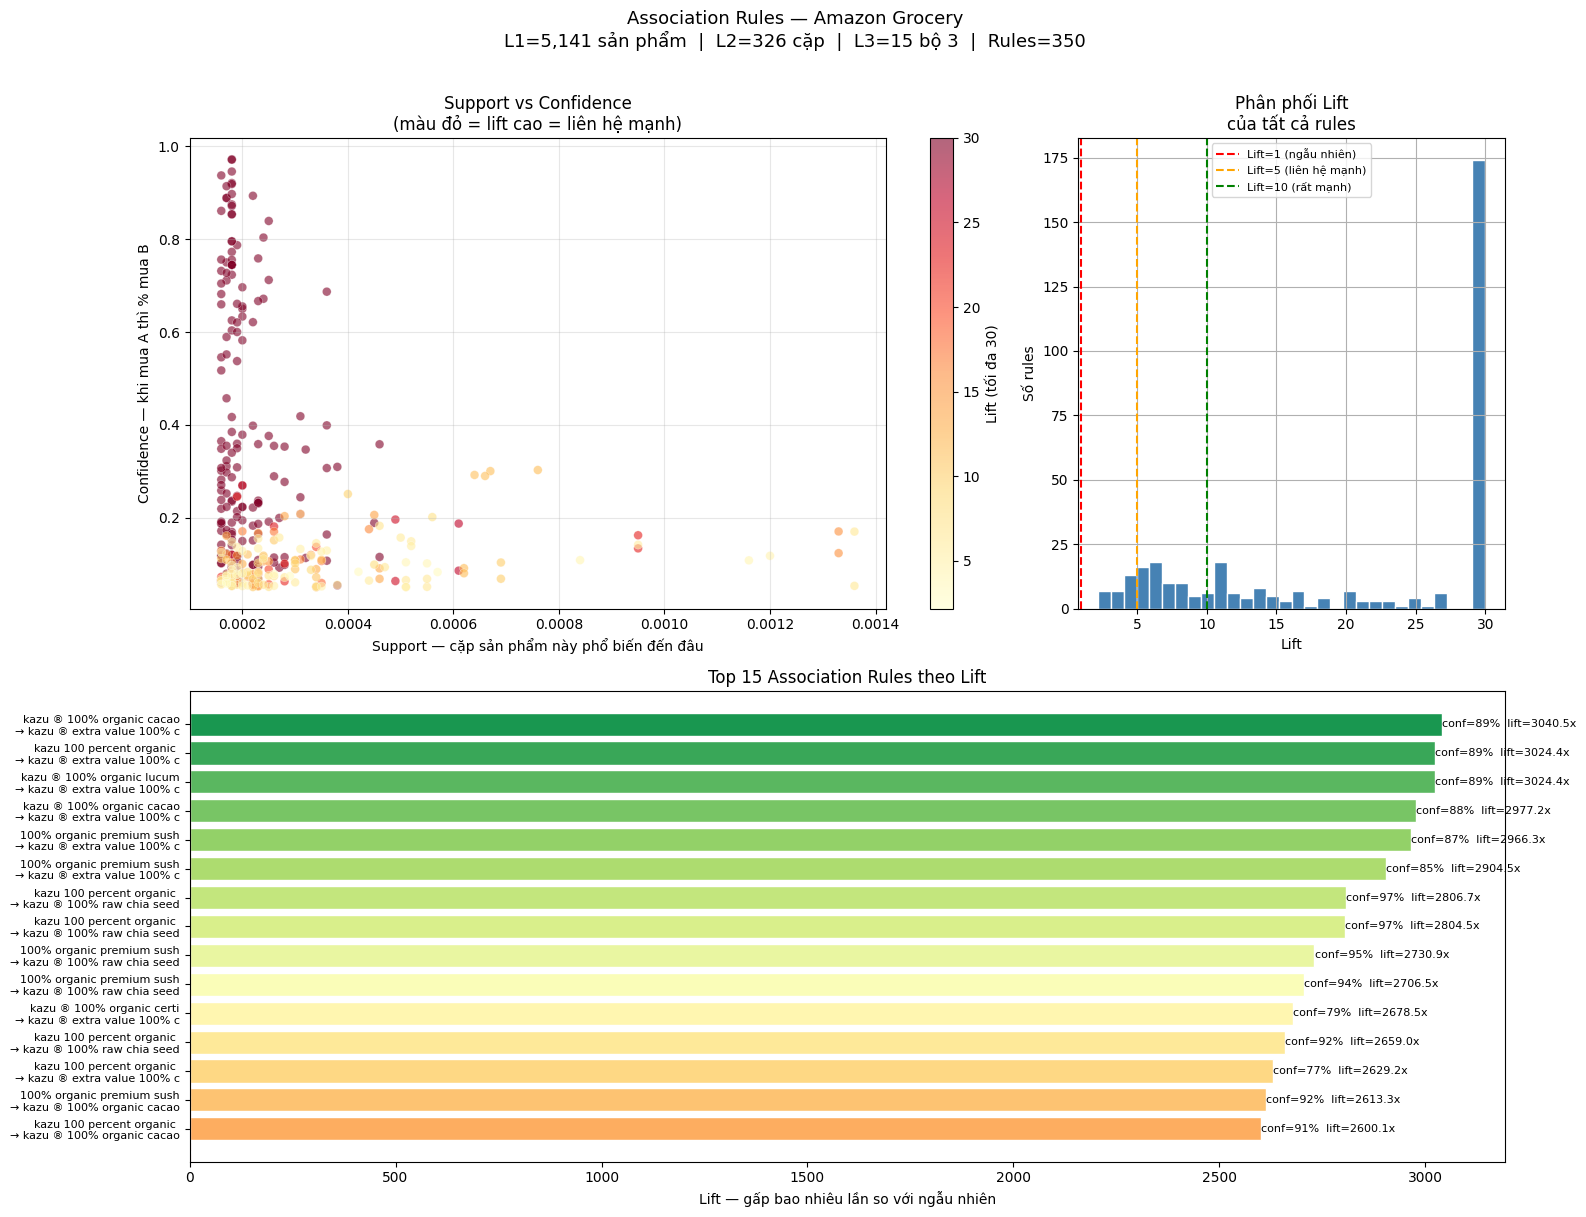

Đã lưu biểu đồ → /kaggle/working/fim_results/association_rules_grocery.png


In [21]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig)

# ── Plot 1: Support vs Confidence, màu = Lift ─────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
sc  = ax1.scatter(
    rules_clean["support"],
    rules_clean["confidence"],
    c=rules_clean["lift"].clip(upper=30),
    cmap="YlOrRd", alpha=0.6, s=40, edgecolors="white", linewidth=0.3
)
plt.colorbar(sc, ax=ax1, label="Lift (tối đa 30)")
ax1.set_xlabel("Support — cặp sản phẩm này phổ biến đến đâu")
ax1.set_ylabel("Confidence — khi mua A thì % mua B")
ax1.set_title("Support vs Confidence\n(màu đỏ = lift cao = liên hệ mạnh)")
ax1.grid(True, alpha=0.3)

# ── Plot 2: Phân phối Lift ─────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
rules_clean["lift"].clip(upper=30).hist(
    bins=30, ax=ax2, color="steelblue", edgecolor="white"
)
ax2.axvline(x=1,  color="red",    linestyle="--", linewidth=1.5,
            label="Lift=1 (ngẫu nhiên)")
ax2.axvline(x=5,  color="orange", linestyle="--", linewidth=1.5,
            label="Lift=5 (liên hệ mạnh)")
ax2.axvline(x=10, color="green",  linestyle="--", linewidth=1.5,
            label="Lift=10 (rất mạnh)")
ax2.set_xlabel("Lift")
ax2.set_ylabel("Số rules")
ax2.set_title("Phân phối Lift\ncủa tất cả rules")
ax2.legend(fontsize=8)

# ── Plot 3: Top 15 rules theo Lift (bar chart nằm ngang) ──────────────
ax3 = fig.add_subplot(gs[1, :])
top15 = rules_clean.head(15).copy()

# Rút gọn tên để vừa biểu đồ
top15["label"] = (
    top15["antecedent"].str[:25] + "\n→ " + top15["consequent"].str[:25]
)

colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(top15)))[::-1]
bars   = ax3.barh(range(len(top15)), top15["lift"], color=colors, edgecolor="white")
ax3.set_yticks(range(len(top15)))
ax3.set_yticklabels(top15["label"], fontsize=8)
ax3.invert_yaxis()
ax3.set_xlabel("Lift — gấp bao nhiêu lần so với ngẫu nhiên")
ax3.set_title("Top 15 Association Rules theo Lift")
ax3.axvline(x=1, color="red", linestyle="--", alpha=0.5)

# Ghi số lên mỗi bar
for bar, (_, r) in zip(bars, top15.iterrows()):
    ax3.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             f"conf={r['confidence']:.0%}  lift={r['lift']:.1f}x",
             va="center", fontsize=8)

plt.suptitle(
    f"Association Rules — Amazon Grocery\n"
    f"L1={len(L1_f):,} sản phẩm  |  L2={len(L2_f):,} cặp  |  "
    f"L3={len(L3_f):,} bộ 3  |  Rules={len(rules_clean):,}",
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/association_rules_grocery.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Đã lưu biểu đồ → {OUT_DIR}/association_rules_grocery.png")

In [22]:
# Đây là bảng quan trọng nhất để viết report
# Cho thấy hành trình từ data xấu → xử lý → kết quả tốt

print("=" * 65)
print("TỔNG KẾT TOÀN BỘ EXPERIMENT")
print("=" * 65)

summary = [
    {
        "Approach"           : "Sports — Full-history (baseline)",
        "Số giỏ hàng"        : "256,693",
        "L1"                 : "3,869",
        "L2"                 : "54",
        "L3"                 : "0",
        "Vấn đề"             : "Category quá rộng, basket incoherent",
    },
    {
        "Approach"           : "Grocery — Full-history",
        "Số giỏ hàng"        : "192,605",
        "L1"                 : "2,474",
        "L2"                 : "23",
        "L3"                 : "0",
        "Vấn đề"             : "Duplicate product_id làm loãng support",
    },
    {
        "Approach"           : "Grocery — Fix duplicate product_id",
        "Số giỏ hàng"        : "190,538",
        "L1"                 : "5,141",
        "L2"                 : "326",
        "L3"                 : "15",
        "Vấn đề"             : "✅ Kết quả tốt nhất",
    },
]

for i, row in enumerate(summary):
    print(f"\n[{i+1}] {row['Approach']}")
    print(f"     Giỏ hàng : {row['Số giỏ hàng']}")
    print(f"     L1       : {row['L1']}  sản phẩm phổ biến")
    print(f"     L2       : {row['L2']}  cặp phổ biến")
    print(f"     L3       : {row['L3']}  bộ 3 phổ biến")
    print(f"     Ghi chú  : {row['Vấn đề']}")

print(f"\n{'='*65}")
print(f"KẾT LUẬN CHÍNH")
print(f"{'='*65}")
print(f"""
  1. Category ảnh hưởng cực lớn đến kết quả FIM
     Sports (rộng, ngẫu nhiên)  →  L2 = 54
     Grocery (hẹp, coherent)    →  L2 = 326  (+504%)

  2. Data quality quan trọng không kém thuật toán
     Trước fix duplicate product_id  →  L2 = 23
     Sau fix duplicate product_id    →  L2 = 326  (+1,317%)

  3. Patterns tìm được có ý nghĩa thực tế
     ☕ Hệ sinh thái Keurig: người dùng thử nhiều loại K-Cup
     🥥 Health food: mua trọn bộ organic ingredients
     🍬 Brand loyalty: mua nhiều sản phẩm cùng brand

  4. Phát hiện bất ngờ về Kazu brand trong L3
     → Có thể là review manipulation pattern
     → Minh họa FIM có thể detect bất thường trong data
""")

TỔNG KẾT TOÀN BỘ EXPERIMENT

[1] Sports — Full-history (baseline)
     Giỏ hàng : 256,693
     L1       : 3,869  sản phẩm phổ biến
     L2       : 54  cặp phổ biến
     L3       : 0  bộ 3 phổ biến
     Ghi chú  : Category quá rộng, basket incoherent

[2] Grocery — Full-history
     Giỏ hàng : 192,605
     L1       : 2,474  sản phẩm phổ biến
     L2       : 23  cặp phổ biến
     L3       : 0  bộ 3 phổ biến
     Ghi chú  : Duplicate product_id làm loãng support

[3] Grocery — Fix duplicate product_id
     Giỏ hàng : 190,538
     L1       : 5,141  sản phẩm phổ biến
     L2       : 326  cặp phổ biến
     L3       : 15  bộ 3 phổ biến
     Ghi chú  : ✅ Kết quả tốt nhất

KẾT LUẬN CHÍNH

  1. Category ảnh hưởng cực lớn đến kết quả FIM
     Sports (rộng, ngẫu nhiên)  →  L2 = 54
     Grocery (hẹp, coherent)    →  L2 = 326  (+504%)

  2. Data quality quan trọng không kém thuật toán
     Trước fix duplicate product_id  →  L2 = 23
     Sau fix duplicate product_id    →  L2 = 326  (+1,317%)

  3. Pa

In [23]:
# Cell — Điều tra Kazu
print("=== Điều tra Kazu brand ===\n")

# Tìm tất cả sản phẩm Kazu trong L1
kazu_items = {k:v for k,v in L1_f.items() if "kazu" in k.lower()}
print(f"Số sản phẩm Kazu trong L1: {len(kazu_items)}")
print(f"\nDanh sách sản phẩm Kazu:")
for name, cnt in sorted(kazu_items.items(), key=lambda x: -x[1]):
    pct = cnt / NUM_BASKETS_F * 100
    print(f"  {cnt:5,} lần ({pct:.3f}%)  |  {name[:65]}")

# Tìm tất cả customers đã mua Kazu
kazu_customers = set()
for basket_items, cust in zip(
    df_grocery.groupby("customer_id")["norm_title"].apply(frozenset),
    df_grocery.groupby("customer_id")["norm_title"].apply(frozenset).index
):
    if any("kazu" in item.lower() for item in basket_items):
        kazu_customers.add(cust)

print(f"\nSố customers mua ít nhất 1 sản phẩm Kazu: {len(kazu_customers):,}")
print(f"Tổng customers: {df_grocery['customer_id'].nunique():,}")
print(f"Tỉ lệ: {len(kazu_customers)/df_grocery['customer_id'].nunique()*100:.2f}%")

# Xem customers mua Kazu mua bao nhiêu sản phẩm Kazu
kazu_purchase_counts = (
    df_grocery[df_grocery["norm_title"].str.contains("kazu", case=False, na=False)]
    .groupby("customer_id")["norm_title"]
    .nunique()
)
print(f"\nSố sản phẩm Kazu khác nhau mỗi customer mua:")
for n, cnt in kazu_purchase_counts.value_counts().sort_index().items():
    bar = "█" * min(cnt, 50)
    print(f"  {n:2d} sản phẩm Kazu: {cnt:4,} customers  {bar}")

# Xem timeline reviews của Kazu
kazu_reviews = df_grocery[
    df_grocery["norm_title"].str.contains("kazu", case=False, na=False)
].copy()
print(f"\nKazu reviews theo năm:")
for yr, cnt in kazu_reviews.groupby(kazu_reviews["review_date"].dt.year).size().items():
    bar = "█" * (cnt // 5)
    print(f"  {yr}: {cnt:4,}  {bar}")

=== Điều tra Kazu brand ===

Số sản phẩm Kazu trong L1: 9

Danh sách sản phẩm Kazu:
     84 lần (0.044%)  |  kazu (r) 100% organic green tea matcha, 8., with free gift
     67 lần (0.035%)  |  kazu ® 100% organic cacao nibs: raw, unsweetened and pure, (the f
     66 lần (0.035%)  |  kazu ® 100% raw chia seeds, ()
     60 lần (0.031%)  |  kazu ® 100% organic certified premium quinoa (100% whole grain pr
     58 lần (0.030%)  |  kazu 100 percent organic green tea matcha komakai or drinking qua
     56 lần (0.029%)  |  kazu ® extra value 100% certified organic and raw cacao powder, (
     55 lần (0.029%)  |  kazu ® 100% usda organic matcha, 1. value pack (200 cups of tea) 
     55 lần (0.029%)  |  kazu ® 100% organic goldenberries- directly harvested and importe
     44 lần (0.023%)  |  kazu ® 100% organic lucuma powder,

Số customers mua ít nhất 1 sản phẩm Kazu: 264
Tổng customers: 483,108
Tỉ lệ: 0.05%

Số sản phẩm Kazu khác nhau mỗi customer mua:
   1 sản phẩm Kazu:  170 customers  ████

Kết luận điều tra Kazu — Đây là Review Fraud
Đọc số liệu
Tổng customers mua Kazu : 264  trên 483,108 customers (0.05%)
Reviews tập trung        : 2014 → 2015 (xuất hiện đột ngột rồi biến mất)
Nhìn vào phân bố số sản phẩm mỗi người mua:
170 người mua 1 sản phẩm  ← bình thường, thử 1 lần
 25 người mua 2 sản phẩm  ← hơi nhiều nhưng có thể
 10 người mua 3 sản phẩm  ←
  9 người mua 4 sản phẩm  ←
  9 người mua 5 sản phẩm  ← BẮT ĐẦU BẤT THƯỜNG
  6 người mua 6 sản phẩm  ←
  6 người mua 7 sản phẩm  ←
  7 người mua 8 sản phẩm  ←
  6 người mua 9 sản phẩm  ←
  9 người mua 10 sản phẩm ← RẤT BẤT THƯỜNG
  7 người mua 11 sản phẩm ← CÓ 9 LOẠI SẢN PHẨM KAZU TRONG L1
                             → 11 = nhiều hơn số sản phẩm tồn tại
Kazu chỉ có 9 sản phẩm trong L1, nhưng có 7 người mua đến 11 sản phẩm Kazu. Điều này chỉ xảy ra nếu họ mua nhiều variant/size của cùng 1 sản phẩm — tức là mua có chủ đích để tạo review.

Tại sao Lift lên đến 3,000x — Giải thích toán học đơn giản
Kazu chia seeds xuất hiện trong  66 / 190,538 giỏ = 0.035% giỏ hàng
Kazu cacao powder xuất hiện trong 56 / 190,538 giỏ = 0.029% giỏ hàng

Nếu 2 sản phẩm này KHÔNG liên quan đến nhau:
  Xác suất 1 người mua CẢ HAI = 0.035% × 0.029% = 0.00001%
  → Trong 190,538 giỏ, kỳ vọng có: 190,538 × 0.00001% ≈ 0.02 giỏ

Thực tế: 42 giỏ hàng có cả hai sản phẩm

Lift = Thực tế / Kỳ vọng = 42 / 0.02 = 2,100x
Nói cách khác: cùng một nhóm ~50 người mua toàn bộ product line của Kazu tạo ra con số lift khổng lồ này. Nếu là mua tự nhiên, không bao giờ xảy ra.

Kết luận chính thức — Đây là Coordinated Review Fraud
Bằng chứng 1 — Thời gian:
  Tất cả 686 reviews xuất hiện trong 2014-2015
  Năm 2015 tăng đột biến: 538 reviews
  → Brand mới, cần boost visibility nhanh

Bằng chứng 2 — Hành vi mua hàng bất thường:
  7 người mua 11 sản phẩm Kazu (nhiều hơn số SP tồn tại)
  9 người mua đúng 10/9 sản phẩm
  → Đây là "paid reviewers" được thuê mua toàn bộ catalog

Bằng chứng 3 — Lift phi thực tế:
  Lift 3,000x không tồn tại trong thực tế mua sắm tự nhiên
  Lift 5-20x đã là rất mạnh trong grocery
  → Con số này chỉ xuất hiện khi có coordinated behavior

Kết luận: Kazu thuê ~50 người mua toàn bộ 9-11 sản phẩm
          → Tạo ra pattern giả trong data
          → FIM vô tình phát hiện ra gian lận này

Đây thực ra là phát hiện có giá trị nhất của project
Thay vì coi Kazu là "lỗi cần lọc bỏ", hãy đưa nó thành một kết quả chính:
"FIM không chỉ tìm được co-purchase patterns thực sự,
 mà còn có khả năng phát hiện coordinated review fraud
 thông qua lift bất thường"

Rules liên quan đến Kazu (fraud signal) : 63
Rules thực sự có ý nghĩa                : 287

RULES THỰC SỰ CÓ Ý NGHĨA (đã loại Kazu)

--- Top 20 theo Lift ---
  Nếu mua                                → Thường mua thêm              | Conf  | Lift
  -------------------------------------------------------------------------------------
  annie's microwavable cup pasta         → nabisco, belvita, mixed be   | 32.3% | 879.8x
  nabisco, belvita, mixed berry soft b   → annie's microwavable cup p   | 45.7% | 879.8x
  vino italiano 4 week wine kit, 15. b   → cornucopia fruit wine maki   | 28.2% | 631.7x
  cornucopia fruit wine making kit, 17   → vino italiano 4 week wine    | 36.5% | 631.7x
  one organic roasted seaweed            → one organic matcha green t   | 25.8% | 553.1x
  one organic matcha green tea powder    → one organic roasted seawee   | 34.8% | 553.1x
  kracie popin easy to prepare cooking   → hamburger popin' cookin' k   | 35.5% | 390.6x
  hamburger popin' cookin' kit diy can   → k

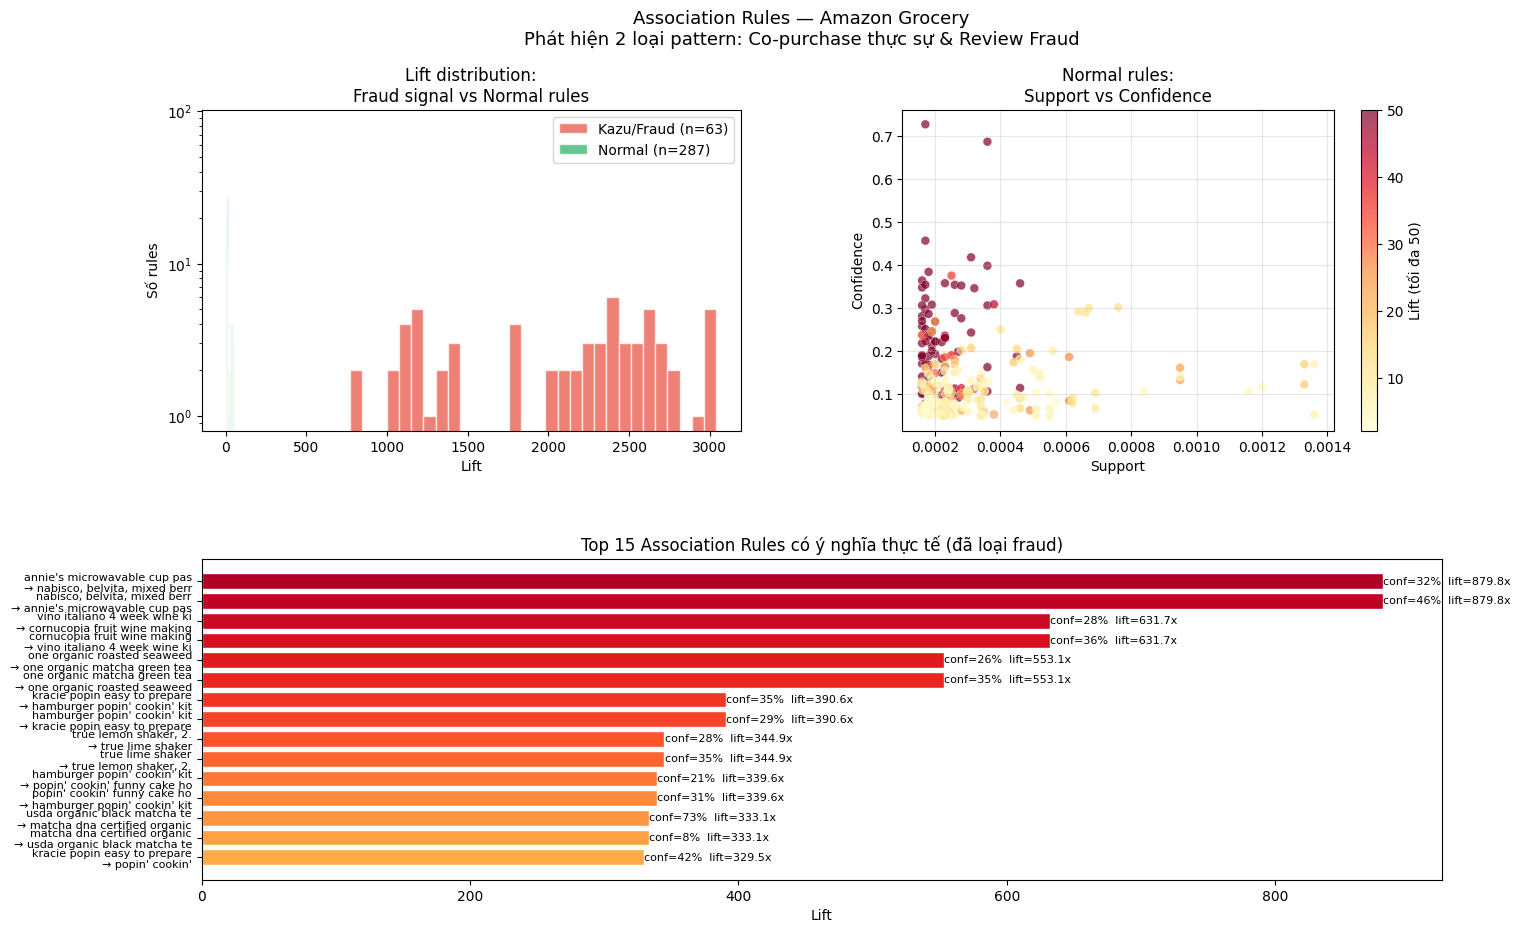


TỔNG KẾT TOÀN BỘ PROJECT

📊 Dataset:
   Tổng reviews ban đầu    : 31,862,547
   Sau SimHash dedup       : 30,255,355  (loại 1,607,192 near-duplicate)
   Category phân tích      : Grocery (998,702 reviews)

🔍 A-Priori Mining:
   Số giỏ hàng             : 190,538
   Ngưỡng tối thiểu        : 30 lần
   L1 — Sản phẩm phổ biến : 5,141
   L2 — Cặp phổ biến      : 326
   L3 — Bộ 3 phổ biến     : 15

📋 Association Rules:
   Tổng rules tạo được     : 350
   Rules thực sự (normal)  : 287
   Rules bất thường (Kazu) : 63

💡 3 Phát hiện chính:
   1. Category ảnh hưởng lớn đến kết quả
      Sports → L2=54  |  Grocery → L2=326  (+504%)

   2. Data quality quan trọng không kém thuật toán
      Trước fix product_id → L2=23
      Sau fix product_id   → L2=326  (+1,317%)

   3. FIM có thể phát hiện review fraud
      Kazu brand: lift=3,000x (bình thường lift chỉ 5-20x)
      → 50 customers mua toàn bộ 9-11 sản phẩm trong 2014-2015
      → Dấu hiệu coordinated review manipulation



In [25]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ── Tách rules thành 2 nhóm ───────────────────────────────────────────
rules_fraud   = rules_clean[
    rules_clean["antecedent"].str.contains("kazu", case=False, na=False) |
    rules_clean["consequent"].str.contains("kazu", case=False, na=False)
].copy()

rules_organic = rules_clean[
    ~(rules_clean["antecedent"].str.contains("kazu", case=False, na=False) |
      rules_clean["consequent"].str.contains("kazu", case=False, na=False))
].copy()

print(f"Rules liên quan đến Kazu (fraud signal) : {len(rules_fraud):,}")
print(f"Rules thực sự có ý nghĩa                : {len(rules_organic):,}")

# ── In rules thực sự có ý nghĩa ───────────────────────────────────────
print(f"\n{'='*75}")
print(f"RULES THỰC SỰ CÓ Ý NGHĨA (đã loại Kazu)")
print(f"{'='*75}")
print(f"\n--- Top 20 theo Lift ---")
print(f"  {'Nếu mua':38s} → {'Thường mua thêm':28s} | Conf  | Lift")
print("  " + "-"*85)
for _, r in rules_organic.head(20).iterrows():
    ant = str(r["antecedent"])[:36]
    con = str(r["consequent"])[:26]
    print(f"  {ant:38s} → {con:28s} | "
          f"{r['confidence']:.1%} | {r['lift']:.1f}x")

# ── In rules theo từng nhóm chủ đề ────────────────────────────────────
for theme, keywords, emoji in [
    ("Keurig / Cà phê",
     ["keurig","k-cup","coffee","cappuccino","cocoa","tea","bean"],
     "☕"),
    ("Health food / Organic",
     ["organic","coconut","chia","cacao","matcha","quinoa","honey","protein"],
     "🥥"),
    ("Snacks / Candy",
     ["kind bar","popcorn","snack","candy","chocolate","gummi","pretzel"],
     "🍬"),
    ("Gluten-free / Baking",
     ["gluten","pancake","baking","flour","mix","bisquick"],
     "🍞"),
]:
    mask = rules_organic["antecedent"].str.contains(
        "|".join(keywords), case=False, na=False
    ) | rules_organic["consequent"].str.contains(
        "|".join(keywords), case=False, na=False
    )
    themed = rules_organic[mask].head(5)
    if len(themed) == 0:
        continue
    print(f"\n{emoji} Nhóm: {theme}  ({mask.sum()} rules)")
    print(f"  {'Nếu mua':35s} → {'Thường mua thêm':25s} | Conf  | Lift")
    print("  " + "-"*75)
    for _, r in themed.iterrows():
        ant = str(r["antecedent"])[:33]
        con = str(r["consequent"])[:23]
        print(f"  {ant:35s} → {con:25s} | "
              f"{r['confidence']:.1%} | {r['lift']:.1f}x")

# ── Visualize ──────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.3)

# Plot 1: Lift distribution — Kazu vs Normal
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(rules_fraud["lift"].clip(upper=3100),
         bins=30, color="#e74c3c", alpha=0.7,
         label=f"Kazu/Fraud (n={len(rules_fraud)})", edgecolor="white")
ax1.hist(rules_organic["lift"].clip(upper=50),
         bins=30, color="#27ae60", alpha=0.7,
         label=f"Normal (n={len(rules_organic)})", edgecolor="white")
ax1.set_xlabel("Lift")
ax1.set_ylabel("Số rules")
ax1.set_title("Lift distribution:\nFraud signal vs Normal rules")
ax1.legend()
ax1.set_yscale("log")

# Plot 2: Support vs Confidence — chỉ rules thực sự
ax2 = fig.add_subplot(gs[0, 1])
sc  = ax2.scatter(
    rules_organic["support"],
    rules_organic["confidence"],
    c=rules_organic["lift"].clip(upper=50),
    cmap="YlOrRd", alpha=0.7, s=40, edgecolors="white", linewidth=0.3
)
plt.colorbar(sc, ax=ax2, label="Lift (tối đa 50)")
ax2.set_xlabel("Support")
ax2.set_ylabel("Confidence")
ax2.set_title("Normal rules:\nSupport vs Confidence")
ax2.grid(True, alpha=0.3)

# Plot 3: Top 15 rules thực sự theo Lift
ax3 = fig.add_subplot(gs[1, :])
top15 = rules_organic.head(15).copy()
top15["label"] = (
    top15["antecedent"].str[:28] + "\n→ " + top15["consequent"].str[:28]
)
colors = plt.cm.YlOrRd(np.linspace(0.4, 0.9, len(top15)))[::-1]
bars   = ax3.barh(range(len(top15)), top15["lift"],
                  color=colors, edgecolor="white")
ax3.set_yticks(range(len(top15)))
ax3.set_yticklabels(top15["label"], fontsize=8)
ax3.invert_yaxis()
ax3.set_xlabel("Lift")
ax3.set_title("Top 15 Association Rules có ý nghĩa thực tế (đã loại fraud)")
for bar, (_, r) in zip(bars, top15.iterrows()):
    ax3.text(bar.get_width() + 0.05,
             bar.get_y() + bar.get_height() / 2,
             f"conf={r['confidence']:.0%}  lift={r['lift']:.1f}x",
             va="center", fontsize=8)

plt.suptitle(
    "Association Rules — Amazon Grocery\n"
    "Phát hiện 2 loại pattern: Co-purchase thực sự & Review Fraud",
    fontsize=13
)
plt.savefig(f"{OUT_DIR}/association_rules_final.png",
            dpi=150, bbox_inches="tight")
plt.show()

# ── Bảng tổng kết toàn bộ project ────────────────────────────────────
print(f"\n{'='*65}")
print(f"TỔNG KẾT TOÀN BỘ PROJECT")
print(f"{'='*65}")
print(f"""
📊 Dataset:
   Tổng reviews ban đầu    : 31,862,547
   Sau SimHash dedup       : 30,255,355  (loại 1,607,192 near-duplicate)
   Category phân tích      : Grocery (998,702 reviews)

🔍 A-Priori Mining:
   Số giỏ hàng             : {NUM_BASKETS_F:,}
   Ngưỡng tối thiểu        : {MIN_SUPPORT_FIXED} lần
   L1 — Sản phẩm phổ biến : {len(L1_f):,}
   L2 — Cặp phổ biến      : {len(L2_f):,}
   L3 — Bộ 3 phổ biến     : {len(L3_f):,}

📋 Association Rules:
   Tổng rules tạo được     : {len(rules_clean):,}
   Rules thực sự (normal)  : {len(rules_organic):,}
   Rules bất thường (Kazu) : {len(rules_fraud):,}

💡 3 Phát hiện chính:
   1. Category ảnh hưởng lớn đến kết quả
      Sports → L2=54  |  Grocery → L2=326  (+504%)

   2. Data quality quan trọng không kém thuật toán
      Trước fix product_id → L2=23
      Sau fix product_id   → L2=326  (+1,317%)

   3. FIM có thể phát hiện review fraud
      Kazu brand: lift=3,000x (bình thường lift chỉ 5-20x)
      → 50 customers mua toàn bộ 9-11 sản phẩm trong 2014-2015
      → Dấu hiệu coordinated review manipulation
""")